# RLHF Distortion Simulation Suite

Simulation framework for studying **social welfare distortion** under **anonymous RLHF**,  
based on the framework in *Social Alignment via RLHF* (the paper).

---

## Pipeline Overview

```
DataGeneratingProcess
  └── agents θ_n ~ N(μ_g, Σ_g)     [grouped Gaussians; diagonal or random-ellipsoid Σ_g]
  └── queries α_z ~ Gaussian or Power-law  [topic-weighted; train ≠ deploy distribution]
  └── labels c ~ Bernoulli(σ(α_z^T θ_n))  [BTL model]
        ↓
AnonymousRLHF
  └── fit pooled multinomial logit → θ̂   [sklearn LogisticRegression]
        ↓
WelfareCalculator
  └── W_n^*(z)   = max(α_z^T θ_n, 0)          [idealized / argmax]
  └── W_n(θ; z)  = (α_z^T θ_n) · σ(α_z^T θ) [softmax, Eq. 6]
  └── compare: idealized | utilitarian-optimal θ̄ | RLHF θ̂
        ↓
AlignmentExternality
  └── IF estimate: Γ^m_{n,z} = ∇W_m^T J^{-1} s_{n,z}  (Eq. 12)
  └── Closed-form:  Γ_{n,z}^{social} = score_{n,z} · α_z^T η  (Eq. 16)
  └── Leave-one-out (LOO) ground truth
```

**Key objects from the paper:**
- θ_n ∈ R^k : agent preference vector  
- α_z ∈ R^k : query feature difference φ(x,y) − φ(x,y')  
- θ̄ = Σ_n w_n θ_n : utilitarian preference  
- θ̂ : RLHF-fitted parameter (pooled BTL MLE)  
- W_n(θ) = E_z[α_z^T θ_n · σ(α_z^T θ)] : agent n's deployment welfare (Eq. 6)  
- Γ^m_{n,z} : alignment externality — how agent n's data affects agent m's welfare (Def. 1)


In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.special import expit as sigmoid   # σ(t) = 1/(1+e^{-t})
from scipy.linalg import inv
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from dataclasses import dataclass
from typing import Optional
import warnings

try:
    from sklearn.exceptions import ConvergenceWarning
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
except ImportError:
    pass

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
colors = sns.color_palette("muted")

---
## 1. Data-Generating Process

**Model (linear preferences + BTL binary choice):**

- Individual utility: $u_n(y|x) = \phi(x,y)^\top \theta_n$ &emsp; (Eq. 3)
- Preference sampling: $\theta_n \sim \mathcal{N}(\mu_g, \Sigma_g)$ for group $g$.  
  $\Sigma_g$ can be **diagonal** (dimension-specific noise) or a **random ellipsoid** (scaled Wishart).
- Query features: $\alpha_z = \phi(x,y) - \phi(x,y')$, sampled either as isotropic Gaussian or via a **power-law topic distribution** — one dominant dimension per query drawn from topic weights, with Gamma-distributed magnitude. Train and deploy distributions can differ.
- Binary label: $c \mid (n,z) \sim \text{Bernoulli}(\sigma(\alpha_z^\top \theta_n))$ &emsp; (BTL model, Eq. 1)

**Training vs. deployment query distributions** differ in general:  
$q_\text{train} \in \Delta_{N \times Z}$ (who labels which queries), $q_\text{dep}$ over $Z$ (real-world usage).  
A key distortion mechanism is when training queries are unrepresentative of deployment.


In [107]:
@dataclass
class DGPConfig:
    """All knobs for the synthetic data-generating process."""
    n_agents:        int   = 50
    k_dim:           int   = 8
    n_train_queries: int   = 500
    n_deploy_queries: int  = 200
    n_groups:        int   = 2
    group_weights:   Optional[np.ndarray] = None
    seed:            int   = 42
    base_cov_scale:  float = 1.0
    cov_delta:       float = 0.5
    mean_separation: float = 1.0        # legacy: offset group 1 along dim 0 only

    # ── Group mean structure ──────────────────────────────────────────────
    mean_magnitude: float = 1.0
    dim_agreement:  Optional[np.ndarray] = None

    # ── Direct group parameterization (overrides dim_agreement) ──────────
    group_mean_vectors:  Optional[list] = None   # list of (k,) arrays, one per group

    # Covariance — three options, checked in order:
    #   1. group_dim_variances: diagonal Σ_g = diag(σ²) — interpretable, dim-specific noise
    #   2. group_cov_scales:    random-orientation ellipsoid scaled by a scalar
    #   3. base_cov_scale + cov_delta: legacy random ellipsoid
    group_dim_variances: Optional[list] = None   # list of (k,) variance arrays → diag cov
    group_cov_scales:    Optional[list] = None   # list of floats → scaled random ellipsoid

    # ── Distortion levers ─────────────────────────────────────────────────
    group_sizes:       Optional[list]        = None
    train_group_fracs: Optional[list]        = None
    train_query_mean:  Optional[np.ndarray]  = None
    deploy_query_mean: Optional[np.ndarray]  = None
    query_scale:       float                 = 1.0

    # ── Query distribution type ────────────────────────────────────────────
    # "gaussian" : α_z ~ N(mean, scale²·I)  [default]
    # "powerlaw" : dominant dimension drawn from topic_weights; magnitude Gamma-distributed
    query_type:           str                  = "gaussian"
    train_topic_weights:  Optional[np.ndarray] = None
    deploy_topic_weights: Optional[np.ndarray] = None


class DataGeneratingProcess:
    """
    Generates:
      - Agent preference vectors  θ_n  ∈ R^k  (grouped Gaussians)
      - Query feature differences α_z  ∈ R^k  (Gaussian or power-law)
      - Labels c | (n,z) ~ Bernoulli(σ(α_z^T θ_n))  [BTL model]
    """

    def __init__(self, cfg: DGPConfig):
        self.cfg = cfg
        self.rng = np.random.default_rng(cfg.seed)
        self._build()

    def _build(self):
        cfg = self.cfg
        k, N = cfg.k_dim, cfg.n_agents

        # ── Assign agents to groups ────────────────────────────────────
        if cfg.group_sizes is not None:
            assert sum(cfg.group_sizes) == N, "group_sizes must sum to n_agents"
            group_ids, start = [], 0
            for size in cfg.group_sizes:
                group_ids.append(np.arange(start, start + size))
                start += size
        else:
            group_ids = np.array_split(np.arange(N), cfg.n_groups)

        self.agent_groups = np.zeros(N, dtype=int)
        for g, ids in enumerate(group_ids):
            self.agent_groups[ids] = g
        self._group_ids = group_ids

        # ── Group means ────────────────────────────────────────────────
        if cfg.group_mean_vectors is not None:
            base_means = [np.asarray(m, dtype=float) for m in cfg.group_mean_vectors]
        elif cfg.dim_agreement is not None:
            agreement = np.asarray(cfg.dim_agreement, dtype=float)
            assert len(agreement) == k
            base_means = [
                np.full(k,  cfg.mean_magnitude),
                agreement * cfg.mean_magnitude,
            ]
        else:
            base_means = []
            for g in range(len(group_ids)):
                m = np.zeros(k)
                m[0] = g * cfg.mean_separation
                base_means.append(m)

        # ── Per-group covariance and preference samples ────────────────
        thetas, self.group_means, self.group_covs = [], [], []
        for g, ids in enumerate(group_ids):
            mean_g = base_means[g] if g < len(base_means) else np.zeros(k)

            if cfg.group_dim_variances is not None:
                # Option 1: diagonal covariance — dimension-specific noise, no cross-dim correlations
                cov_g = np.diag(np.asarray(cfg.group_dim_variances[g], dtype=float))
            elif cfg.group_cov_scales is not None:
                # Option 2: random-orientation ellipsoid with specified overall scale
                A_g   = self.rng.standard_normal((k, k))
                cov_g = cfg.group_cov_scales[g] * (A_g @ A_g.T) / k
            else:
                # Option 3: legacy random ellipsoid
                A_g   = self.rng.standard_normal((k, k))
                cov_g = cfg.base_cov_scale * (1 + g * cfg.cov_delta) * (A_g @ A_g.T) / k

            thetas.append(self.rng.multivariate_normal(mean_g, cov_g, size=len(ids)))
            self.group_means.append(mean_g)
            self.group_covs.append(cov_g)

        self.theta = np.vstack(thetas)  # (N, k)

        # ── Social welfare weights ─────────────────────────────────────
        if cfg.group_weights is not None:
            self.w = cfg.group_weights / cfg.group_weights.sum()
        else:
            self.w = np.ones(N) / N

        self.theta_bar = (self.w[:, None] * self.theta).sum(0)  # (k,)

        # ── Query feature vectors ─────────────────────────────────────
        self.alpha_train  = self._sample_queries(cfg.n_train_queries,
                                                  cfg.train_query_mean,
                                                  cfg.train_topic_weights)
        self.alpha_deploy = self._sample_queries(cfg.n_deploy_queries,
                                                  cfg.deploy_query_mean,
                                                  cfg.deploy_topic_weights)

        self._generate_training_data()

    def _sample_queries(self, n: int,
                        mean: Optional[np.ndarray] = None,
                        topic_weights: Optional[np.ndarray] = None) -> np.ndarray:
        """Sample query feature vectors.

        "gaussian" (default): α_z ~ N(mean, scale²·I).
        "powerlaw": each query has one dominant dimension drawn from topic_weights;
                    magnitude is Gamma-distributed (right-skewed, like query complexity).
                    Other dimensions get small Gaussian background noise.
        """
        if self.cfg.query_type == "powerlaw" and topic_weights is not None:
            return self._sample_queries_powerlaw(n, topic_weights)
        raw = self.cfg.query_scale * self.rng.standard_normal((n, self.cfg.k_dim))
        if mean is not None:
            raw = raw + mean
        return raw

    def _sample_queries_powerlaw(self, n: int, topic_weights: np.ndarray) -> np.ndarray:
        """Power-law query distribution.

        Each query has one dominant dimension (its "topic") drawn from topic_weights,
        representing the skewed frequency of real query types (many routine queries
        on popular topics, few complex specialized ones).  The dominant dimension
        gets a Gamma-distributed spike (right-skewed signal strength); all other
        dimensions get small Gaussian background noise.
        """
        k = self.cfg.k_dim
        scale = self.cfg.query_scale
        probs = np.array(topic_weights, dtype=float)
        probs /= probs.sum()

        dominant   = self.rng.choice(k, size=n, p=probs)
        alpha      = self.rng.standard_normal((n, k)) * (scale * 0.3)
        magnitudes = self.rng.gamma(shape=2.0, scale=scale, size=n)
        signs      = self.rng.choice([-1.0, 1.0], size=n)
        alpha[np.arange(n), dominant] += signs * magnitudes
        return alpha

    def _generate_training_data(self):
        cfg   = self.cfg
        n_obs = cfg.n_train_queries
        N     = cfg.n_agents

        if cfg.train_group_fracs is not None:
            fracs = np.array(cfg.train_group_fracs, dtype=float)
            fracs = fracs / fracs.sum()
            p = np.zeros(N)
            for g, ids in enumerate(self._group_ids):
                p[ids] = fracs[g] / len(ids)
            p /= p.sum()
            agent_idx = self.rng.choice(N, size=n_obs, p=p)
        else:
            agent_idx = self.rng.integers(0, N, size=n_obs)

        query_idx = self.rng.integers(0, cfg.n_train_queries, size=n_obs)
        alpha_z   = self.alpha_train[query_idx]
        logits    = (alpha_z * self.theta[agent_idx]).sum(1)
        probs     = sigmoid(logits)
        labels    = self.rng.binomial(1, probs).astype(float)

        self.train_agent_idx   = agent_idx
        self.train_query_idx   = query_idx
        self.train_alpha       = alpha_z
        self.train_labels      = labels
        self.train_logits_true = logits


In [108]:
# ── Instantiate baseline DGP ──────────────────────────────────────────────
baseline_cfg = DGPConfig(
    n_agents=50, k_dim=8, n_train_queries=1000, n_deploy_queries=200,
    n_groups=2, mean_separation=1.0, cov_delta=0.5, seed=42,
)
dgp = DataGeneratingProcess(baseline_cfg)

print(f"Agents: {baseline_cfg.n_agents}  |  k={baseline_cfg.k_dim}  |  Groups: {baseline_cfg.n_groups}")
print(f"Training obs: {baseline_cfg.n_train_queries}  |  Deploy queries: {baseline_cfg.n_deploy_queries}")
print(f"\nθ̄ (utilitarian mean): {dgp.theta_bar.round(3)}")
print(f"Group sizes: { {g: (dgp.agent_groups == g).sum() for g in range(baseline_cfg.n_groups)} }")
print(f"Per-group theta_n mean (dim 0 only):")
for g in range(baseline_cfg.n_groups):
    m = dgp.theta[dgp.agent_groups == g, 0].mean()
    print(f"  Group {g}: {m:.3f}  (expected μ[0] = {g * baseline_cfg.mean_separation:.1f})")

Agents: 50  |  k=8  |  Groups: 2
Training obs: 1000  |  Deploy queries: 200

θ̄ (utilitarian mean): [ 0.512 -0.002 -0.033  0.266  0.427 -0.083 -0.053 -0.339]
Group sizes: {0: 25, 1: 25}
Per-group theta_n mean (dim 0 only):
  Group 0: 0.107  (expected μ[0] = 0.0)
  Group 1: 0.917  (expected μ[0] = 1.0)


---
## 2. Anonymous RLHF Fitting

**Anonymous RLHF** treats all $(n, z)$ observations as draws from a single representative agent —  
it pools labels without conditioning on who answered.

The estimator solves the **BTL / multinomial logit MLE**:

$$\hat{\theta}^{\text{RLHF}} = \arg\min_\theta\; \mathcal{L}_{\text{RLHF}}(\theta) = -\mathbb{E}_{(n,z) \sim q_\text{train}}\left[c \log \sigma(\alpha_z^\top \theta) + (1-c)\log(1-\sigma(\alpha_z^\top \theta))\right]$$

This is an **M-projection** of the pooled choice frequencies onto the single-parameter logistic family.  
Sklearn's `LogisticRegression` with no intercept and large `C` approximates this MLE.  

**Key distortion:** $\hat{\theta}^{\text{RLHF}} \neq \bar{\theta}$ in general — the pooled MLE does not recover the utilitarian preference.

In [109]:
class AnonymousRLHF:
    """
    Fits a single θ̂ by pooling all (agent, query) pairs.
    Uses sklearn LogisticRegression (no intercept, near-unregularized) to
    approximate the BTL MLE.
    """

    def __init__(self, C: float = 1e6):
        self.C = C
        self.theta_hat: Optional[np.ndarray] = None
        self.model: Optional[LogisticRegression] = None

    def fit(self, alpha: np.ndarray, labels: np.ndarray) -> np.ndarray:
        """
        alpha  : (n_obs, k)  query difference vectors
        labels : (n_obs,)    binary choices {0, 1}
        Returns theta_hat : (k,)
        """
        lr = LogisticRegression(
            fit_intercept=False, C=self.C,
            solver="lbfgs", max_iter=2000, tol=1e-8,
        )
        lr.fit(alpha, labels)
        self.theta_hat = lr.coef_.ravel()
        self.model = lr
        return self.theta_hat

    def predict_proba(self, alpha: np.ndarray) -> np.ndarray:
        """σ(α^T θ̂) for each query."""
        return sigmoid(alpha @ self.theta_hat)

||θ̂_RLHF - θ̄|| = 0.4428
||θ̂_RLHF||      = 0.4471
||θ̄||            = 0.8007

cosine(θ̂, θ̄)   = 0.9007


/var/folders/yr/f3z1jw3j2390b9qngzcf_8mh0000gn/T/ipykernel_45639/839559559.py:36: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
/var/folders/yr/f3z1jw3j2390b9qngzcf_8mh0000gn/T/ipykernel_45639/839559559.py:36: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  plt.tight_layout()
/var/folders/yr/f3z1jw3j2390b9qngzcf_8mh0000gn/T/ipykernel_45639/839559559.py:36: UserWarning: Glyph 8869 (\N{UP TACK}) missing from current font.
  plt.tight_layout()
/Users/michellesi/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/michellesi/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/michellesi/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtoo

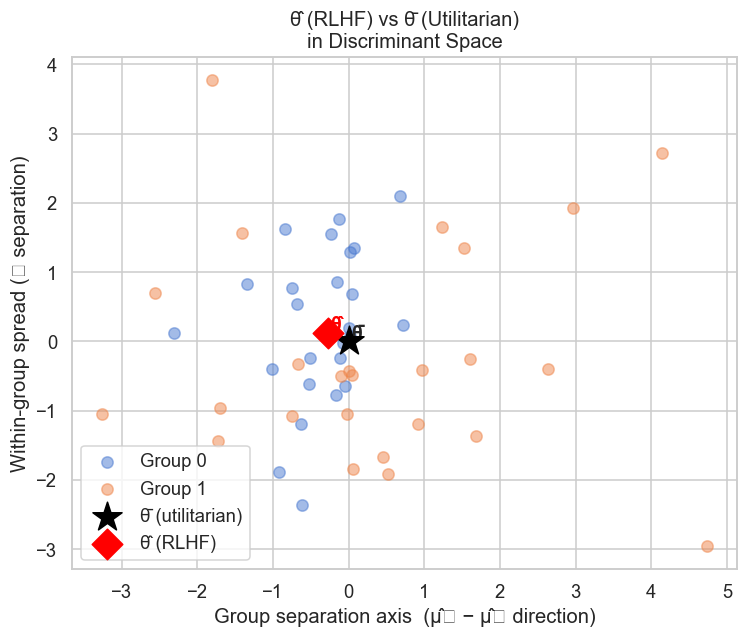

In [110]:
# ── Fit anonymous RLHF on baseline data ──────────────────────────────────
rlhf = AnonymousRLHF()
rlhf.fit(dgp.train_alpha, dgp.train_labels)

theta_dist = np.linalg.norm(rlhf.theta_hat - dgp.theta_bar)
print(f"||θ̂_RLHF - θ̄|| = {theta_dist:.4f}")
print(f"||θ̂_RLHF||      = {np.linalg.norm(rlhf.theta_hat):.4f}")
print(f"||θ̄||            = {np.linalg.norm(dgp.theta_bar):.4f}")
print(f"\ncosine(θ̂, θ̄)   = {np.dot(rlhf.theta_hat, dgp.theta_bar) / (np.linalg.norm(rlhf.theta_hat) * np.linalg.norm(dgp.theta_bar)):.4f}")

# ── PCA projection for visualization ────────────────────────────────────
from sklearn.decomposition import PCA
_pca = PCA(n_components=2).fit(dgp.theta)
project_2d = _pca.transform
theta_2d   = project_2d(dgp.theta)    # (N, 2)

# ── Visualize θ̂ vs θ̄ in discriminant space ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
for g in range(baseline_cfg.n_groups):
    mask = dgp.agent_groups == g
    ax.scatter(theta_2d[mask, 0], theta_2d[mask, 1],
               color=colors[g], label=f"Group {g}", alpha=0.5, s=55)

th_2d = project_2d(rlhf.theta_hat[None, :])[0]
tb_2d = project_2d(dgp.theta_bar[None, :])[0]

ax.scatter(*tb_2d, marker='*', s=400, color='black', zorder=6, label='θ̄ (utilitarian)')
ax.scatter(*th_2d, marker='D', s=200, color='red',   zorder=6, label='θ̂ (RLHF)')
ax.annotate('θ̄', tb_2d + 0.03, fontsize=13, fontweight='bold')
ax.annotate('θ̂', th_2d + 0.03, fontsize=13, color='red', fontweight='bold')

ax.set_xlabel("Group separation axis  (μ̂₁ − μ̂₀ direction)")
ax.set_ylabel("Within-group spread (⊥ separation)")
ax.set_title("θ̂ (RLHF) vs θ̄ (Utilitarian)\nin Discriminant Space")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Welfare Calculation

We use the **two-outcome** welfare function: the model chooses A with probability $\sigma(\alpha_z^\top\theta)$
and B with probability $1 - \sigma(\alpha_z^\top\theta)$, giving expected utility:

$$W_n(\theta; z) = 2\,\alpha_z^\top\theta_n\,\left(\sigma(\alpha_z^\top\theta) - \tfrac{1}{2}\right)$$

A random model ($\theta = 0$) gives $W_n = 0$. Three decision rules on **deployment** queries $q_\text{dep}$:

| Rule | Formula | Description |
|------|---------|-------------|
| **Idealized (argmax)** | $W_n^*(z) = \lvert\alpha_z^\top \theta_n\rvert$ | Agent makes own optimal choice |
| **Utilitarian optimal** | $W_n(\bar{\theta}; z) = 2(\alpha_z^\top \theta_n)(\sigma(\alpha_z^\top \bar{\theta}) - \tfrac{1}{2})$ | Model with true social-planner prefs |
| **RLHF** | $W_n(\hat{\theta}; z) = 2(\alpha_z^\top \theta_n)(\sigma(\alpha_z^\top \hat{\theta}) - \tfrac{1}{2})$ | Deployed anonymous RLHF model |

All three are averaged over deployment queries: $W_n = \mathbb{E}_{z \sim q_\text{dep}}[\cdots]$

**Welfare decomposition:**
$$\underbrace{W_n^* - W_n(\hat{\theta})}_{\text{total loss}} = \underbrace{W_n^* - W_n(\bar{\theta})}_{\text{delegation loss}} + \underbrace{W_n(\bar{\theta}) - W_n(\hat{\theta})}_{\text{RLHF distortion}}$$

**Utilitarian social welfare:**  $W(\theta) = \sum_n w_n W_n(\theta)$

In [111]:
class WelfareCalculator:
    """
    Computes deployment welfare under the two-outcome BTL model:

      W_n(θ; z) = 2 (α_z^T θ_n)(σ(α_z^T θ) − ½)

    This is the expected utility when the model chooses A with probability σ
    and B with probability 1−σ:  σ·u(A) + (1−σ)·u(B)  where u(A)=α^Tθ_n, u(B)=−α^Tθ_n.
    A random model (θ=0) gives welfare = 0.

    Idealized welfare: W_n^*(z) = |α_z^T θ_n|  (agent always picks preferred option).
    """

    def __init__(self, dgp: DataGeneratingProcess):
        self.dgp = dgp

    # ------------------------------------------------------------------
    def agent_welfare_softmax(self, theta: np.ndarray) -> np.ndarray:
        """
        W_n(theta) for every agent, averaged over deployment queries.
        W_n(z; θ) = 2 (α_z^T θ_n) (σ(α_z^T θ) − ½)
        Returns: (N,)
        """
        alpha  = self.dgp.alpha_deploy       # (Q_dep, k)
        thetas = self.dgp.theta              # (N, k)

        agent_logits = thetas @ alpha.T                   # (N, Q_dep)  α_z^T θ_n
        model_probs  = sigmoid(alpha @ theta)             # (Q_dep,)   σ(α_z^T θ)

        welfare_nz = 2.0 * agent_logits * (model_probs[None, :] - 0.5)  # (N, Q_dep)
        return welfare_nz.mean(axis=1)       # (N,)

    # ------------------------------------------------------------------
    def agent_welfare_argmax(self) -> np.ndarray:
        """
        Idealized welfare: agent always picks their preferred option.
        W_n^*(z) = |α_z^T θ_n|
        Returns: (N,)
        """
        alpha  = self.dgp.alpha_deploy       # (Q_dep, k)
        thetas = self.dgp.theta              # (N, k)
        agent_logits = thetas @ alpha.T      # (N, Q_dep)
        return np.abs(agent_logits).mean(axis=1)  # (N,)

    # ------------------------------------------------------------------
    def welfare_loss(self, theta: np.ndarray) -> np.ndarray:
        """Per-agent loss vs. idealized: W_n^* - W_n(theta). Returns: (N,)"""
        return self.agent_welfare_argmax() - self.agent_welfare_softmax(theta)

    def rlhf_distortion(self, theta_rlhf: np.ndarray,
                        theta_bar: Optional[np.ndarray] = None) -> np.ndarray:
        """Per-agent RLHF distortion: W_n(θ̄) - W_n(θ̂). Returns: (N,)"""
        if theta_bar is None:
            theta_bar = self.dgp.theta_bar
        return self.agent_welfare_softmax(theta_bar) - self.agent_welfare_softmax(theta_rlhf)

    def delegation_loss(self, theta_bar: Optional[np.ndarray] = None) -> np.ndarray:
        """Per-agent delegation loss: W_n^* - W_n(θ̄). Returns: (N,)"""
        if theta_bar is None:
            theta_bar = self.dgp.theta_bar
        return self.agent_welfare_argmax() - self.agent_welfare_softmax(theta_bar)

    # ------------------------------------------------------------------
    def social_welfare(self, theta: np.ndarray) -> float:
        """Utilitarian social welfare W(θ) = Σ_n w_n W_n(θ)."""
        return float(self.dgp.w @ self.agent_welfare_softmax(theta))

    def social_welfare_argmax(self) -> float:
        """Idealized social welfare Σ_n w_n W_n^*."""
        return float(self.dgp.w @ self.agent_welfare_argmax())

    # ------------------------------------------------------------------
    def summarize(self, theta_rlhf: np.ndarray,
                  theta_bar: Optional[np.ndarray] = None) -> pd.DataFrame:
        """Full per-agent welfare breakdown."""
        if theta_bar is None:
            theta_bar = self.dgp.theta_bar

        W_ideal = self.agent_welfare_argmax()
        W_opt   = self.agent_welfare_softmax(theta_bar)
        W_rlhf  = self.agent_welfare_softmax(theta_rlhf)

        return pd.DataFrame({
            "group":            self.dgp.agent_groups,
            "W_ideal":          W_ideal,
            "W_opt":            W_opt,
            "W_rlhf":           W_rlhf,
            "rlhf_distortion":  W_opt  - W_rlhf,
            "delegation_loss":  W_ideal - W_opt,
            "total_loss":       W_ideal - W_rlhf,
            "rlhf_ratio":       np.where(np.abs(W_opt) > 1e-10,   W_rlhf / W_opt,   np.nan),
            "total_ratio":      np.where(np.abs(W_ideal) > 1e-10, W_rlhf / W_ideal, np.nan),
            "deleg_ratio":      np.where(np.abs(W_ideal) > 1e-10, W_opt  / W_ideal, np.nan),
        })

In [112]:
# ── Compute welfare breakdown ─────────────────────────────────────────────
welfare = WelfareCalculator(dgp)
welfare_df = welfare.summarize(rlhf.theta_hat, dgp.theta_bar)

sw_ideal = welfare.social_welfare_argmax()
sw_opt   = welfare.social_welfare(dgp.theta_bar)
sw_rlhf  = welfare.social_welfare(rlhf.theta_hat)

print("=" * 55)
print("Social Welfare Summary")
print("=" * 55)
print(f"  W_ideal (argmax, individual):   {sw_ideal:.4f}")
print(f"  W_opt   (softmax, θ̄):           {sw_opt:.4f}")
print(f"  W_RLHF  (softmax, θ̂):           {sw_rlhf:.4f}")
print(f"  RLHF distortion (W_opt - W_RLHF): {sw_opt - sw_rlhf:.4f}")
print(f"  Delegation loss (W_ideal - W_opt): {sw_ideal - sw_opt:.4f}")
print()
print("Per-group averages:")
print(welfare_df.groupby("group")[
    ["W_ideal", "W_opt", "W_rlhf", "rlhf_distortion", "delegation_loss"]
].mean().round(4).to_string())

Social Welfare Summary
  W_ideal (argmax, individual):   2.2453
  W_opt   (softmax, θ̄):           0.2953
  W_RLHF  (softmax, θ̂):           0.1625
  RLHF distortion (W_opt - W_RLHF): 0.1328
  Delegation loss (W_ideal - W_opt): 1.9500

Per-group averages:
       W_ideal   W_opt  W_rlhf  rlhf_distortion  delegation_loss
group                                                           
0       1.7100  0.0510  0.0309           0.0201            1.659
1       2.7806  0.5396  0.2942           0.2455            2.241


---
## 4. Alignment Externalities

The **alignment externality** $\Gamma^m_{n,z}$ measures the marginal effect on agent $m$'s welfare  
from infinitesimally upweighting agent $n$'s response to query $z$ in training.

**General influence-function formula (Lemma 2 / Eq. 12):**
$$\Gamma^m_{n,z} = \nabla_\theta W_m(\hat{\theta})^\top \, J(\hat{\theta})^{-1} \, s_{n,z}(\hat{\theta})$$

where:
- $J = \mathbb{E}_{(n,z)}[v(\alpha_z^\top \hat{\theta})\, \alpha_z \alpha_z^\top]$ — Fisher information (population Hessian)
- $s_{n,z} = (\sigma(\alpha_z^\top \theta_n) - \sigma(\alpha_z^\top \hat{\theta}))\, \alpha_z$ — expected score contribution (Eq. 14)
- $\nabla_\theta W_n = \mathbb{E}_z[(\alpha_z^\top \theta_n)\, v(\alpha_z^\top \hat{\theta})\, \alpha_z]$ — welfare gradient (Eq. 14)

**Closed-form for social welfare externality (Eq. 16):**
$$\Gamma^{\text{social}}_{n,z} = (\sigma(\alpha_z^\top \theta_n) - \sigma(\alpha_z^\top \hat{\theta}))\; \alpha_z^\top \eta$$

where $\eta = J^{-1} \nabla_\theta W(\hat{\theta})$ is the **natural gradient of social welfare**.

**Proposition 1:** $\mathbb{E}_{(n,z) \sim q_\text{train}}[\Gamma^{\text{social}}_{n,z}] = 0$  
→ Under- and over-representation must average out across the training mixture.

In [113]:
class AlignmentExternality:
    """
    Computes alignment externalities via two methods:

    Method A – General Influence Function (IF)  [Lemma 2, Eq. 12]
        Γ^m_{n,z} = ∇_θ W_m(θ̂)^T J^{-1} s_{n,z}(θ̂)   — per-agent externality

        s_{n,z} uses the EXPECTED score (σ(α^T θ_n) − σ(α^T θ̂))·α rather than the
        observed label residual (y − σ(α^T θ̂))·α. These are equal in expectation
        (E[y] = σ_true), matching the paper's Eq. 14 / closed-form Eq. 16.
        This measures the *inclusion benefit* of observation (n,z): positive = including
        this observation increases social welfare.

    Method B – Closed-form Social Welfare Externality  [Eq. 16]
        Γ^social_{n,z} = (σ(α_z^T θ_n) - σ(α_z^T θ̂)) · α_z^T η
        where η = J^{-1} ∇_θ W(θ̂)  — natural gradient of social welfare

    Method C – Leave-One-Out (LOO)  [ground truth]
        Re-fit RLHF without obs (n,z), return W(θ̂) − W(θ̂_{-i}).
        This is the *cost of removal* = benefit of inclusion, matching the sign of IF.
        (Note: returns W_full − W_loo, not W_loo − W_full.)
    """

    def __init__(self, dgp: DataGeneratingProcess, rlhf: AnonymousRLHF,
                 welfare_calc: WelfareCalculator):
        self.dgp     = dgp
        self.rlhf    = rlhf
        self.welfare = welfare_calc
        self._precompute()

    def _precompute(self):
        """Precompute J, J^{-1}, welfare gradients ∇W_n, and η."""
        theta = self.rlhf.theta_hat         # (k,)
        alpha = self.dgp.train_alpha        # (n_obs, k)
        n_obs = alpha.shape[0]

        # Fisher information J = (1/n) Σ_i v_i α_i α_i^T
        p_hat = sigmoid(alpha @ theta)                          # (n_obs,)
        v_hat = p_hat * (1 - p_hat)                             # σ(1-σ)
        self.J     = (alpha * v_hat[:, None]).T @ alpha / n_obs  # (k, k)
        self.J_inv = inv(self.J + 1e-8 * np.eye(self.J.shape[0]))

        # Deployment quantities
        alpha_dep = self.dgp.alpha_deploy                       # (Q_dep, k)
        p_dep     = sigmoid(alpha_dep @ theta)                  # (Q_dep,)
        v_dep     = p_dep * (1 - p_dep)                         # (Q_dep,)
        thetas    = self.dgp.theta                              # (N, k)

        # ── Per-agent welfare gradients ∇_θ W_n  (Eq. 14) ──────────
        # ∇_θ W_n = E_z[(α_z^T θ_n) · v(α_z^T θ̂) · α_z]
        agent_logits_dep = thetas @ alpha_dep.T                 # (N, Q_dep)
        self.welfare_grads = (
            (agent_logits_dep[:, :, None] * v_dep[None, :, None]) * alpha_dep[None, :, :]
        ).mean(axis=1)                                          # (N, k)

        # ── Natural gradient of social welfare η = J^{-1} ∇_θ W  ───
        sw_grad = ((alpha_dep @ self.dgp.theta_bar) * v_dep)[:, None] * alpha_dep
        sw_grad = sw_grad.mean(axis=0)                          # (k,)
        self.eta = self.J_inv @ sw_grad                         # (k,)

    # ── Score function (expected, per paper's Eq. 14) ─────────────────────
    def score(self, obs_idx: int) -> np.ndarray:
        """
        Expected score s_{n,z}(θ̂) = (σ(α_z^T θ_n) − σ(α_z^T θ̂)) · α_z.
        Uses the true agent probability, not the observed label — equals the
        standard MLE score in expectation. (Paper Eq. 14)
        """
        theta   = self.rlhf.theta_hat
        alpha_z = self.dgp.train_alpha[obs_idx]         # (k,)
        n       = self.dgp.train_agent_idx[obs_idx]
        theta_n = self.dgp.theta[n]
        return (sigmoid(alpha_z @ theta_n) - sigmoid(alpha_z @ theta)) * alpha_z

    # ── Method A: General IF — per-agent externality ─────────────────────
    def influence_externality(self, obs_idx: int) -> np.ndarray:
        """
        Γ^m_{n,z} for all m simultaneously.  (Lemma 2 / Eq. 12)
        Positive = including this observation increases agent m's welfare.
        Returns: (N,)
        """
        s       = self.score(obs_idx)           # (k,)
        J_inv_s = self.J_inv @ s                # (k,)
        return self.welfare_grads @ J_inv_s     # (N,)

    def aggregate_if_externalities(self) -> np.ndarray:
        """E_{n,z}[Γ^m_{n,z}] — should ≈ 0 per Prop. 1. Returns: (N,)"""
        n_obs  = self.dgp.train_alpha.shape[0]
        gammas = np.stack([self.influence_externality(i) for i in range(n_obs)])
        return gammas.mean(axis=0)

    # ── Method B: Closed-form social welfare externality (Eq. 16) ────────
    def social_externality_closed_form(self, obs_idx: int) -> float:
        """
        Γ^social_{n,z} = (σ(α_z^T θ_n) − σ(α_z^T θ̂)) · α_z^T η  (Eq. 16)
        """
        theta   = self.rlhf.theta_hat
        alpha_z = self.dgp.train_alpha[obs_idx]
        n       = self.dgp.train_agent_idx[obs_idx]
        theta_n = self.dgp.theta[n]
        score_scalar = sigmoid(alpha_z @ theta_n) - sigmoid(alpha_z @ theta)
        return float(score_scalar * (alpha_z @ self.eta))

    def social_externality_from_if(self, obs_idx: int) -> float:
        """Social welfare externality via general IF: Σ_m w_m Γ^m_{n,z}."""
        return float(self.dgp.w @ self.influence_externality(obs_idx))

    # ── Method C: Leave-One-Out (LOO) ─────────────────────────────────────
    def loo_social_welfare_change(self, obs_idx: int, C: float = 1e6) -> float:
        """
        Re-fit RLHF without observation obs_idx.
        Returns W(θ̂) − W(θ̂_{-i}): the *cost of removal* = benefit of inclusion.
        Sign matches IF externality (positive = this observation helps social welfare).
        """
        mask = np.ones(self.dgp.train_alpha.shape[0], dtype=bool)
        mask[obs_idx] = False

        rlhf_loo = AnonymousRLHF(C=C)
        rlhf_loo.fit(self.dgp.train_alpha[mask], self.dgp.train_labels[mask])

        W_full = self.welfare.social_welfare(self.rlhf.theta_hat)
        W_loo  = self.welfare.social_welfare(rlhf_loo.theta_hat)
        return W_full - W_loo   # cost of removal (was W_loo - W_full — wrong sign)

    # ── IF vs LOO comparison ───────────────────────────────────────────────
    def compare_if_vs_loo(self, n_samples: int = 50, seed: int = 0) -> pd.DataFrame:
        """
        Compare IF estimate vs LOO for a random subset of training observations.
        Both measure the *benefit of inclusion*: positive = this observation helps.
        Columns: obs_idx, agent, group, if_social, closed_form_social, loo_social
        """
        rng   = np.random.default_rng(seed)
        n_obs = self.dgp.train_alpha.shape[0]
        idxs  = rng.choice(n_obs, size=min(n_samples, n_obs), replace=False)

        records = []
        for i in idxs:
            sw_if  = self.social_externality_from_if(i)
            sw_cf  = self.social_externality_closed_form(i)
            sw_loo = self.loo_social_welfare_change(i)
            n_agent = self.dgp.train_agent_idx[i]
            records.append({
                "obs_idx":            i,
                "agent":              n_agent,
                "group":              self.dgp.agent_groups[n_agent],
                "if_social":          sw_if,
                "closed_form_social": sw_cf,
                "loo_social":         sw_loo,
            })

        return pd.DataFrame(records)

In [114]:
# ── Fit externality calculator on baseline ────────────────────────────────
ext = AlignmentExternality(dgp, rlhf, welfare)

# Verify Proposition 1: average externality ≈ 0
avg_ext = ext.aggregate_if_externalities()  # (N,)
sw_avg_ext = float(dgp.w @ avg_ext)

print("Proposition 1 check (average externality should ≈ 0):")
print(f"  Mean per-agent externality: {avg_ext.mean():.6f}")
print(f"  Max |per-agent|:            {np.abs(avg_ext).max():.6f}")
print(f"  Social welfare avg ext:     {sw_avg_ext:.8f}")

# Closed-form vs general IF on a few samples
print("\nClosed-form (Eq.16) vs general IF [should match exactly]:")
for i in np.random.default_rng(0).choice(100, size=5, replace=False):
    cf  = ext.social_externality_closed_form(i)
    gen = ext.social_externality_from_if(i)
    print(f"  obs {i:3d}: closed-form = {cf:+.6f}   general IF = {gen:+.6f}  diff = {abs(cf-gen):.2e}")

Proposition 1 check (average externality should ≈ 0):
  Mean per-agent externality: -0.007763
  Max |per-agent|:            0.080661
  Social welfare avg ext:     -0.00776315

Closed-form (Eq.16) vs general IF [should match exactly]:
  obs  61: closed-form = -0.213799   general IF = -0.213799  diff = 1.67e-16
  obs  50: closed-form = +0.409145   general IF = +0.409145  diff = 1.11e-16
  obs  26: closed-form = -0.095895   general IF = -0.095895  diff = 1.39e-17
  obs  30: closed-form = +0.166436   general IF = +0.166436  diff = 2.78e-17
  obs  81: closed-form = +0.096226   general IF = +0.096226  diff = 2.78e-16


---
## 5. Influence Function vs. Leave-One-Out Validation

We validate the IF approximation by comparing it to the ground-truth LOO change in social welfare.

Good agreement (high correlation, low MAE) means the IF is a reliable cheap proxy for the expensive LOO.

In [115]:
# ── Run IF vs LOO comparison (small DGP for speed) ───────────────────────
loo_cfg = DGPConfig(
    n_agents=30, k_dim=6, n_train_queries=300, n_deploy_queries=100,
    n_groups=2, mean_separation=1.0, cov_delta=0.4, seed=7,
)
loo_dgp     = DataGeneratingProcess(loo_cfg)
loo_rlhf    = AnonymousRLHF()
loo_rlhf.fit(loo_dgp.train_alpha, loo_dgp.train_labels)
loo_welfare = WelfareCalculator(loo_dgp)
loo_ext     = AlignmentExternality(loo_dgp, loo_rlhf, loo_welfare)

loo_df = loo_ext.compare_if_vs_loo(n_samples=80, seed=7)

corr_if_loo = loo_df[["if_social", "loo_social"]].corr().iloc[0, 1]
corr_cf_loo = loo_df[["closed_form_social", "loo_social"]].corr().iloc[0, 1]
mae_if      = (loo_df["if_social"] - loo_df["loo_social"]).abs().mean()
mae_cf      = (loo_df["closed_form_social"] - loo_df["loo_social"]).abs().mean()

print(f"IF  vs LOO — Correlation: {corr_if_loo:.4f}   MAE: {mae_if:.6f}")
print(f"CF  vs LOO — Correlation: {corr_cf_loo:.4f}   MAE: {mae_cf:.6f}")
print("\nSample rows:")
print(loo_df.head(8).round(6).to_string(index=False))

IF  vs LOO — Correlation: 0.3777   MAE: 0.198331
CF  vs LOO — Correlation: 0.3777   MAE: 0.198331

Sample rows:
 obs_idx  agent  group  if_social  closed_form_social  loo_social
     121     16      1  -0.131436           -0.131436   -0.002244
     280      3      0  -0.001048           -0.001048    0.003175
     244      4      0  -0.167338           -0.167338   -0.002244
     174      9      0  -0.215178           -0.215178   -0.004263
      42      1      0   0.241229            0.241229    0.002913
     228     18      1   0.244725            0.244725    0.001922
       9      8      0  -0.178732           -0.178732    0.002587
     274      7      0   0.085502            0.085502    0.000820


In [116]:
# # ── Plot IF vs LOO ────────────────────────────────────────────────────────
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# loo_colors = [colors[g] for g in loo_df["group"]]

# for ax, (xcol, xlabel) in zip(axes, [
#     ("if_social",          "IF Estimate (Eq. 12)"),
#     ("closed_form_social", "Closed-Form Eq. 16"),
# ]):
#     ax.scatter(loo_df[xcol], loo_df["loo_social"],
#                c=loo_colors, alpha=0.75, s=50, edgecolors='white', linewidths=0.4)
#     lim = max(loo_df[[xcol, "loo_social"]].abs().max().max() * 1.1, 1e-6)
#     ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1, label='y=x')
#     ax.set_xlabel(xlabel); ax.set_ylabel("LOO (ground truth)")
#     corr_val = loo_df[[xcol, "loo_social"]].corr().iloc[0, 1]
#     ax.set_title(f"{xlabel}\nCorr = {corr_val:.4f}")
#     ax.legend()

# # Group legend
# for g in range(loo_cfg.n_groups):
#     axes[0].scatter([], [], color=colors[g], label=f"Group {g}", s=40)
# axes[0].legend(fontsize=9)

# plt.suptitle("Influence Function vs. Leave-One-Out Validation", fontweight='bold', y=1.01)
# plt.tight_layout()
# plt.show()

---
## 6. Experiment Infrastructure

`Experiment` wires together DGP → RLHF → WelfareCalculator → AlignmentExternality into a single `.run()` call, returning a standardised result dict used by all sweep functions below.


In [117]:
class Experiment:
    """Wires DGP → RLHF → Welfare → Externalities into one run."""

    def __init__(self, cfg: DGPConfig):
        self.cfg     = cfg
        self.dgp     = DataGeneratingProcess(cfg)
        self.rlhf    = AnonymousRLHF()
        self.welfare = WelfareCalculator(self.dgp)
        self.ext: Optional[AlignmentExternality] = None

    def run(self) -> dict:
        dgp  = self.dgp
        rlhf = self.rlhf

        rlhf.fit(dgp.train_alpha, dgp.train_labels)

        welfare_df = self.welfare.summarize(rlhf.theta_hat, dgp.theta_bar)

        sw_ideal = self.welfare.social_welfare_argmax()
        sw_opt   = self.welfare.social_welfare(dgp.theta_bar)
        sw_rlhf  = self.welfare.social_welfare(rlhf.theta_hat)

        self.ext = AlignmentExternality(dgp, rlhf, self.welfare)
        avg_ext  = self.ext.aggregate_if_externalities()

        return {
            "cfg":             self.cfg,
            "theta_hat":       rlhf.theta_hat,
            "theta_bar":       dgp.theta_bar,
            "theta_dist":      float(np.linalg.norm(rlhf.theta_hat - dgp.theta_bar)),
            "sw_ideal":        sw_ideal,
            "sw_opt":          sw_opt,
            "sw_rlhf":         sw_rlhf,
            "sw_gap":          sw_opt - sw_rlhf,       # RLHF distortion
            "sw_deleg_loss":   sw_ideal - sw_opt,      # delegation loss
            "welfare_df":      welfare_df,
            "avg_externality": avg_ext,
        }


---
## 7. Who Bears the Distortion? Four Levers

The magnitude of RLHF distortion depends on *structural* features of the training and deployment setup.
We sweep over four levers and track **per-group RLHF distortion** $W(\bar\theta) - W(\hat\theta)$ separately for each group.

| Lever | What it changes | Mechanism |
|-------|----------------|-----------|
| **Annotation bias** | Fraction of training labels from each group | θ̂ is pulled toward the over-represented group's preferences |
| **Annotator pool composition** | Number of agents per group | With uniform per-agent sampling, larger groups contribute proportionally more labels |
| **Training query bias** | Mean shift of training queries along dim 0 | Queries biased toward one group's preferred region affect Fisher info and score direction |
| **Deployment query bias** | Mean shift of deployment queries along dim 0 | Mismatch between where preferences are *tested* vs. where the model *operates* |

**DGP setup:** k=8, `n_sep_dims=4` (groups opposed on 4 dims, aligned on 4), independent per-group magnitudes ~ Uniform(0, 5).

**Reading the plots:** Above zero = group bears a positive distortion cost (model underserves them vs θ̄). Below zero = model happens to serve them *better* than θ̄, which can occur when deployment queries are biased toward their preferred region.


In [118]:
def _per_group_distortion(res: dict, n_groups: int) -> dict:
    """Extract mean per-group RLHF distortion from an Experiment result."""
    wdf = res["welfare_df"]
    return {f"distortion_g{g}": wdf[wdf.group == g]["rlhf_distortion"].mean()
            for g in range(n_groups)}


def _base_cfg(n_sep_dims: int = 8, mean_max: float = 5.0, seed: int = 0,
              cov_delta: float = 0.5, **overrides):
    """
    Shared baseline config for the 4-lever sweeps.

    Each group draws its own independent magnitudes per dimension from Uniform(0, mean_max).
    On 'opposed' dimensions (first n_sep_dims), group 1's sign is flipped:

        group 0:  [ +a_0,  +a_1, ...,  +a_{k-1} ]        a_d ~ Uniform(0, mean_max)
        group 1:  [ −b_0, ..., −b_{n_sep−1}, +b_{n_sep}, ..., +b_{k-1} ]  b_d independent

    So on a disagreement dim you might have group 0 = +3.0, group 1 = −1.7.
    """
    k = 8
    rng = np.random.default_rng(seed)
    mag0 = rng.uniform(0.0, mean_max, size=k)
    mag1 = rng.uniform(0.0, mean_max, size=k)
    signs = np.array([-1.0] * n_sep_dims + [+1.0] * (k - n_sep_dims))

    return dict(
        n_agents=200, k_dim=k,
        n_train_queries=4000, n_deploy_queries=200,
        n_groups=2, cov_delta=cov_delta, seed=seed,
        group_mean_vectors=[mag0, signs * mag1],
        **overrides,
    )


def _query_mean(bias: float, k: int) -> Optional[np.ndarray]:
    """Convenience: scalar bias along dim 0 → k-dim mean vector."""
    if bias == 0.0:
        return None
    v = np.zeros(k)
    v[0] = bias
    return v


# ── Lever 1: Training annotation bias ─────────────────────────────────────
def sweep_annotation_bias(group0_fracs=None, n_seeds=1) -> pd.DataFrame:
    group0_fracs = group0_fracs or [0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9]
    records = []
    for f0 in group0_fracs:
        r0s, r1s, tr0s, tr1s = [], [], [], []
        for seed in range(n_seeds):
            cfg = DGPConfig(**_base_cfg(seed=seed), train_group_fracs=[f0, 1 - f0])
            res = Experiment(cfg).run()
            wdf = res["welfare_df"]
            for g, (rl, trl) in enumerate([(r0s, tr0s), (r1s, tr1s)]):
                gdf = wdf[wdf.group == g]
                w_rlhf, w_opt, w_ideal = gdf["W_rlhf"].mean(), gdf["W_opt"].mean(), gdf["W_ideal"].mean()
                rl.append(w_rlhf / w_opt if abs(w_opt) > 1e-10 else np.nan)
                trl.append(w_rlhf / w_ideal if abs(w_ideal) > 1e-10 else np.nan)
        records.append({
            "group0_train_frac":  f0,
            "rlhf_ratio_g0_mean": np.nanmean(r0s),
            "rlhf_ratio_g0_se":   np.nanstd(r0s) / np.sqrt(n_seeds),
            "rlhf_ratio_g1_mean": np.nanmean(r1s),
            "rlhf_ratio_g1_se":   np.nanstd(r1s) / np.sqrt(n_seeds),
            "total_ratio_g0_mean": np.nanmean(tr0s),
            "total_ratio_g0_se":   np.nanstd(tr0s) / np.sqrt(n_seeds),
            "total_ratio_g1_mean": np.nanmean(tr1s),
            "total_ratio_g1_se":   np.nanstd(tr1s) / np.sqrt(n_seeds),
        })
    return pd.DataFrame(records)


# ── Lever 2: Annotator pool composition ───────────────────────────────────
def sweep_pool_composition(group0_fracs=None, n_seeds=1) -> pd.DataFrame:
    group0_fracs = group0_fracs or [0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9]
    N = 200
    records = []
    for f0 in group0_fracs:
        n0 = max(1, round(N * f0))
        r0s, r1s, tr0s, tr1s = [], [], [], []
        for seed in range(n_seeds):
            cfg = DGPConfig(**_base_cfg(seed=seed), group_sizes=[n0, N - n0])
            res = Experiment(cfg).run()
            wdf = res["welfare_df"]
            for g, (rl, trl) in enumerate([(r0s, tr0s), (r1s, tr1s)]):
                gdf = wdf[wdf.group == g]
                w_rlhf, w_opt, w_ideal = gdf["W_rlhf"].mean(), gdf["W_opt"].mean(), gdf["W_ideal"].mean()
                rl.append(w_rlhf / w_opt if abs(w_opt) > 1e-10 else np.nan)
                trl.append(w_rlhf / w_ideal if abs(w_ideal) > 1e-10 else np.nan)
        records.append({
            "group0_pool_frac":   f0,
            "rlhf_ratio_g0_mean": np.nanmean(r0s),
            "rlhf_ratio_g0_se":   np.nanstd(r0s) / np.sqrt(n_seeds),
            "rlhf_ratio_g1_mean": np.nanmean(r1s),
            "rlhf_ratio_g1_se":   np.nanstd(r1s) / np.sqrt(n_seeds),
            "total_ratio_g0_mean": np.nanmean(tr0s),
            "total_ratio_g0_se":   np.nanstd(tr0s) / np.sqrt(n_seeds),
            "total_ratio_g1_mean": np.nanmean(tr1s),
            "total_ratio_g1_se":   np.nanstd(tr1s) / np.sqrt(n_seeds),
        })
    return pd.DataFrame(records)


# ── Lever 3: Training query mean ───────────────────────────────────────────
def sweep_train_query_bias(biases=None, n_seeds=1) -> pd.DataFrame:
    biases = biases or [-2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0]
    k = 8
    records = []
    for b in biases:
        r0s, r1s, tr0s, tr1s = [], [], [], []
        for seed in range(n_seeds):
            cfg = DGPConfig(**_base_cfg(seed=seed), train_query_mean=_query_mean(b, k))
            res = Experiment(cfg).run()
            wdf = res["welfare_df"]
            for g, (rl, trl) in enumerate([(r0s, tr0s), (r1s, tr1s)]):
                gdf = wdf[wdf.group == g]
                w_rlhf, w_opt, w_ideal = gdf["W_rlhf"].mean(), gdf["W_opt"].mean(), gdf["W_ideal"].mean()
                rl.append(w_rlhf / w_opt if abs(w_opt) > 1e-10 else np.nan)
                trl.append(w_rlhf / w_ideal if abs(w_ideal) > 1e-10 else np.nan)
        records.append({
            "train_query_bias":   b,
            "rlhf_ratio_g0_mean": np.nanmean(r0s),
            "rlhf_ratio_g0_se":   np.nanstd(r0s) / np.sqrt(n_seeds),
            "rlhf_ratio_g1_mean": np.nanmean(r1s),
            "rlhf_ratio_g1_se":   np.nanstd(r1s) / np.sqrt(n_seeds),
            "total_ratio_g0_mean": np.nanmean(tr0s),
            "total_ratio_g0_se":   np.nanstd(tr0s) / np.sqrt(n_seeds),
            "total_ratio_g1_mean": np.nanmean(tr1s),
            "total_ratio_g1_se":   np.nanstd(tr1s) / np.sqrt(n_seeds),
        })
    return pd.DataFrame(records)


# ── Lever 4: Deployment query mean ────────────────────────────────────────
def sweep_deploy_query_bias(biases=None, n_seeds=1) -> pd.DataFrame:
    biases = biases or [-2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0]
    k = 8
    records = []
    for b in biases:
        r0s, r1s, tr0s, tr1s = [], [], [], []
        for seed in range(n_seeds):
            cfg = DGPConfig(**_base_cfg(seed=seed), deploy_query_mean=_query_mean(b, k))
            res = Experiment(cfg).run()
            wdf = res["welfare_df"]
            for g, (rl, trl) in enumerate([(r0s, tr0s), (r1s, tr1s)]):
                gdf = wdf[wdf.group == g]
                w_rlhf, w_opt, w_ideal = gdf["W_rlhf"].mean(), gdf["W_opt"].mean(), gdf["W_ideal"].mean()
                rl.append(w_rlhf / w_opt if abs(w_opt) > 1e-10 else np.nan)
                trl.append(w_rlhf / w_ideal if abs(w_ideal) > 1e-10 else np.nan)
        records.append({
            "deploy_query_bias":  b,
            "rlhf_ratio_g0_mean": np.nanmean(r0s),
            "rlhf_ratio_g0_se":   np.nanstd(r0s) / np.sqrt(n_seeds),
            "rlhf_ratio_g1_mean": np.nanmean(r1s),
            "rlhf_ratio_g1_se":   np.nanstd(r1s) / np.sqrt(n_seeds),
            "total_ratio_g0_mean": np.nanmean(tr0s),
            "total_ratio_g0_se":   np.nanstd(tr0s) / np.sqrt(n_seeds),
            "total_ratio_g1_mean": np.nanmean(tr1s),
            "total_ratio_g1_se":   np.nanstd(tr1s) / np.sqrt(n_seeds),
        })
    return pd.DataFrame(records)

Running 4-lever sweeps (k=8, 4 opposed dims, 10 seeds)...
Done.


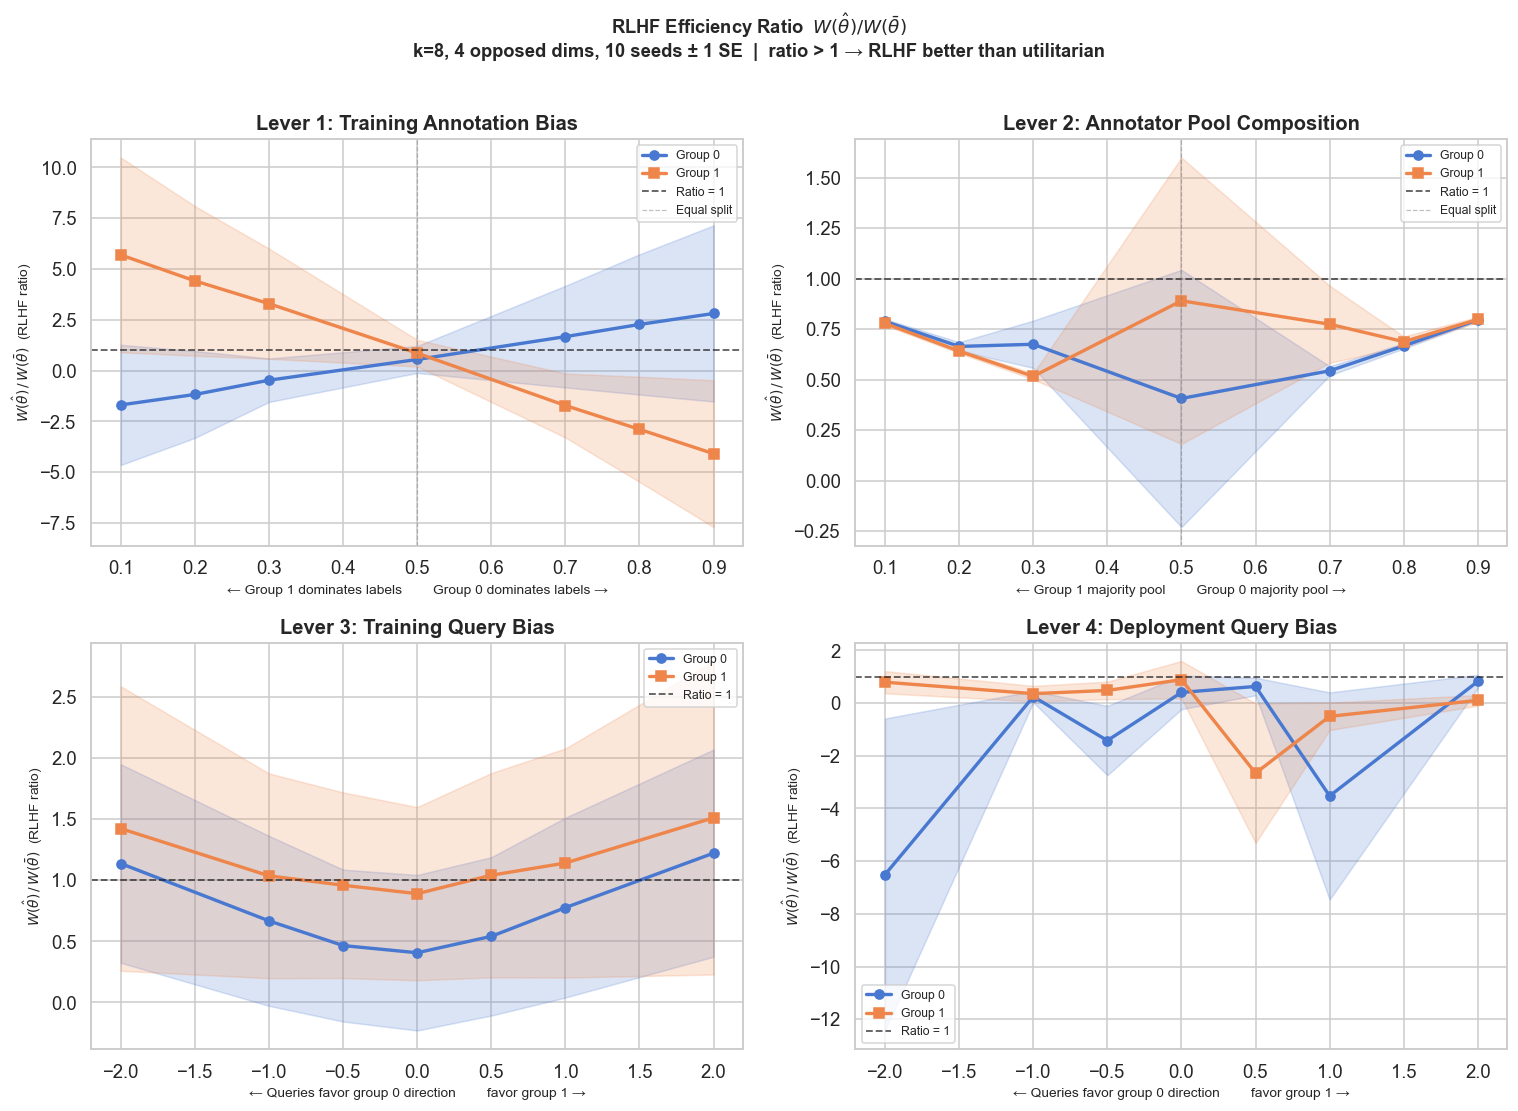

In [119]:
print("Running 4-lever sweeps (k=8, 4 opposed dims, 10 seeds)...")
df_annot   = sweep_annotation_bias(n_seeds=10)
df_pool    = sweep_pool_composition(n_seeds=10)
df_trbias  = sweep_train_query_bias(n_seeds=10)
df_depbias = sweep_deploy_query_bias(n_seeds=10)
print("Done.")

# ── Who Bears the RLHF Distortion? 2×2 panel (RATIO: W(θ̂)/W(θ̄)) ────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

c0, c1 = colors[0], colors[1]

panels = [
    (df_annot,   "group0_train_frac",
     "← Group 1 dominates labels        Group 0 dominates labels →",
     "Lever 1: Training Annotation Bias"),

    (df_pool,    "group0_pool_frac",
     "← Group 1 majority pool        Group 0 majority pool →",
     "Lever 2: Annotator Pool Composition"),

    (df_trbias,  "train_query_bias",
     "← Queries favor group 0 direction        favor group 1 →",
     "Lever 3: Training Query Bias"),

    (df_depbias, "deploy_query_bias",
     "← Queries favor group 0 direction        favor group 1 →",
     "Lever 4: Deployment Query Bias"),
]

for ax, (df, xcol, xlabel, title) in zip(axes.ravel(), panels):
    x = df[xcol]
    m0, s0 = df["rlhf_ratio_g0_mean"], df["rlhf_ratio_g0_se"]
    m1, s1 = df["rlhf_ratio_g1_mean"], df["rlhf_ratio_g1_se"]
    ax.plot(x, m0, 'o-', color=c0, linewidth=2.2, label="Group 0")
    ax.fill_between(x, m0 - s0, m0 + s0, alpha=0.20, color=c0)
    ax.plot(x, m1, 's-', color=c1, linewidth=2.2, label="Group 1")
    ax.fill_between(x, m1 - s1, m1 + s1, alpha=0.20, color=c1)
    ax.axhline(1.0, color='k', linewidth=1.2, linestyle='--', alpha=0.7, label="Ratio = 1")
    if xcol in ("group0_train_frac", "group0_pool_frac"):
        ax.axvline(0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5,
                   label="Equal split")
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(r"$W(\hat{\theta}) \,/\, W(\bar{\theta})$  (RLHF ratio)", fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle(
    r"RLHF Efficiency Ratio  $W(\hat{\theta}) / W(\bar{\theta})$"
    "\nk=8, 4 opposed dims, 10 seeds ± 1 SE  |  ratio > 1 → RLHF better than utilitarian",
    fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

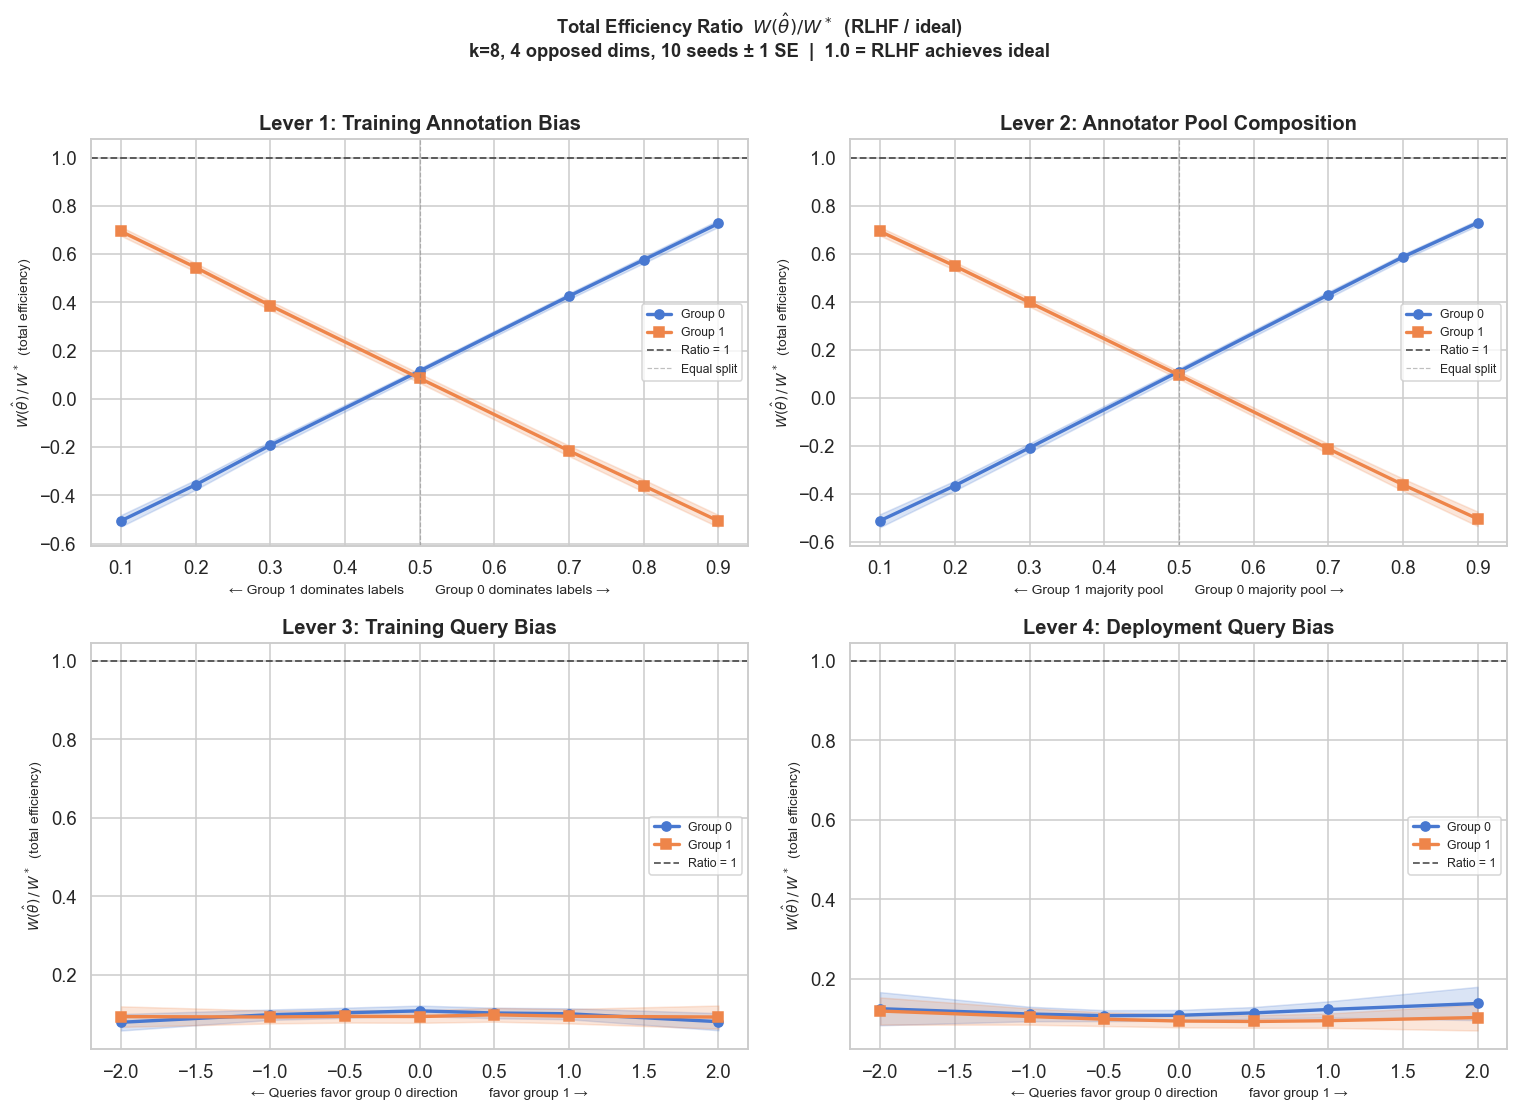

In [120]:
# ── Total Efficiency Ratio  W(θ̂)/W*  2×2 panel ──────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

c0, c1 = colors[0], colors[1]

panels = [
    (df_annot,   "group0_train_frac",
     "← Group 1 dominates labels        Group 0 dominates labels →",
     "Lever 1: Training Annotation Bias"),

    (df_pool,    "group0_pool_frac",
     "← Group 1 majority pool        Group 0 majority pool →",
     "Lever 2: Annotator Pool Composition"),

    (df_trbias,  "train_query_bias",
     "← Queries favor group 0 direction        favor group 1 →",
     "Lever 3: Training Query Bias"),

    (df_depbias, "deploy_query_bias",
     "← Queries favor group 0 direction        favor group 1 →",
     "Lever 4: Deployment Query Bias"),
]

for ax, (df, xcol, xlabel, title) in zip(axes.ravel(), panels):
    x = df[xcol]
    m0, s0 = df["total_ratio_g0_mean"], df["total_ratio_g0_se"]
    m1, s1 = df["total_ratio_g1_mean"], df["total_ratio_g1_se"]
    ax.plot(x, m0, 'o-', color=c0, linewidth=2.2, label="Group 0")
    ax.fill_between(x, m0 - s0, m0 + s0, alpha=0.20, color=c0)
    ax.plot(x, m1, 's-', color=c1, linewidth=2.2, label="Group 1")
    ax.fill_between(x, m1 - s1, m1 + s1, alpha=0.20, color=c1)
    ax.axhline(1.0, color='k', linewidth=1.2, linestyle='--', alpha=0.7, label="Ratio = 1")
    if xcol in ("group0_train_frac", "group0_pool_frac"):
        ax.axvline(0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5,
                   label="Equal split")
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(r"$W(\hat{\theta}) \,/\, W^*$  (total efficiency)", fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle(
    r"Total Efficiency Ratio  $W(\hat{\theta}) / W^*$  (RLHF / ideal)"
    "\nk=8, 4 opposed dims, 10 seeds ± 1 SE  |  1.0 = RLHF achieves ideal",
    fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 8. Heterogeneity and Distortion

**Question:** Holding group sizes and annotation fractions equal (50/50), how does
group 1's *preference distribution shape* affect their RLHF distortion?

Two distinct sources of heterogeneity:

- **Spread** (`cov_delta`): how much more internally diverse group 1 is compared to group 0.
  When group 1 agents disagree more among themselves, their training labels partially cancel
  out in the pooled logistic regression — effectively reducing their influence on θ̂ even with
  equal label counts. Group 0, being more homogeneous, punches above its weight.

- **Preference scale** (`mean_max`): the upper bound of the Uniform(0, mean_max) distribution
  from which each group's per-dimension magnitude is drawn. Higher `mean_max` means groups
  have stronger, more heterogeneous preferences on average — increasing the potential gap
  between θ̄ and θ̂.

**DGP setup throughout:** k=8, `n_sep_dims=4`, independent per-group magnitudes.
We sweep each factor independently, then show their joint effect as a heatmap.


In [121]:
def sweep_spread(cov_deltas=None, mean_max=2.5, n_seeds=5) -> pd.DataFrame:
    """
    Sweep group 1's spread (cov_delta) at fixed preference scale.
    cov_delta=0: both groups same covariance scale (only orientation differs).
    cov_delta=3: group 1 has 4× the spread of group 0.
    Averaged over n_seeds to reduce noise from random covariance draws.
    Uses k=8, 4 opposed dims, independent per-group magnitudes.
    """
    cov_deltas = cov_deltas or [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]
    records = []
    for cd in cov_deltas:
        r0s, r1s = [], []
        for seed in range(n_seeds):
            cfg = DGPConfig(**_base_cfg(n_sep_dims=4, mean_max=mean_max, seed=seed, cov_delta=cd))
            res = Experiment(cfg).run()
            wdf = res["welfare_df"]
            for g, rl in enumerate([r0s, r1s]):
                gdf = wdf[wdf.group == g]
                rl.append(gdf["W_rlhf"].mean() / gdf["W_opt"].mean() if abs(gdf["W_opt"].mean()) > 1e-10 else np.nan)
        records.append({
            "cov_delta":          cd,
            "spread_ratio":       1 + cd,
            "rlhf_ratio_g0_mean": np.nanmean(r0s),
            "rlhf_ratio_g0_se":   np.nanstd(r0s) / np.sqrt(n_seeds),
            "rlhf_ratio_g1_mean": np.nanmean(r1s),
            "rlhf_ratio_g1_se":   np.nanstd(r1s) / np.sqrt(n_seeds),
        })
    return pd.DataFrame(records)


def sweep_mean_scale(mean_maxes=None, cov_delta=0.0, n_seeds=5) -> pd.DataFrame:
    """
    Sweep preference magnitude scale (mean_max) at fixed equal spread.
    mean_max=0: groups have zero mean (pure noise drives distortion).
    mean_max=5: groups have strong, heterogeneous preferences.
    Isolates the effect of how much groups disagree without spread confound.
    """
    mean_maxes = mean_maxes or [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.5, 5.0]
    records = []
    for mm in mean_maxes:
        r0s, r1s = [], []
        for seed in range(n_seeds):
            cfg = DGPConfig(**_base_cfg(n_sep_dims=4, mean_max=mm, seed=seed, cov_delta=cov_delta))
            res = Experiment(cfg).run()
            wdf = res["welfare_df"]
            for g, rl in enumerate([r0s, r1s]):
                gdf = wdf[wdf.group == g]
                rl.append(gdf["W_rlhf"].mean() / gdf["W_opt"].mean() if abs(gdf["W_opt"].mean()) > 1e-10 else np.nan)
        records.append({
            "mean_max":           mm,
            "rlhf_ratio_g0_mean": np.nanmean(r0s),
            "rlhf_ratio_g0_se":   np.nanstd(r0s) / np.sqrt(n_seeds),
            "rlhf_ratio_g1_mean": np.nanmean(r1s),
            "rlhf_ratio_g1_se":   np.nanstd(r1s) / np.sqrt(n_seeds),
        })
    return pd.DataFrame(records)


def heatmap_spread_vs_scale(cov_deltas=None, mean_maxes=None, seed=0) -> pd.DataFrame:
    """2D grid: cov_delta × mean_max → per-group distortion."""
    cov_deltas = cov_deltas or [0.0, 0.5, 1.0, 2.0, 3.0]
    mean_maxes = mean_maxes or [0.5, 1.0, 2.0, 3.5, 5.0]
    records = []
    for cd in cov_deltas:
        for mm in mean_maxes:
            cfg = DGPConfig(**_base_cfg(n_sep_dims=4, mean_max=mm, seed=seed, cov_delta=cd))
            res = Experiment(cfg).run()
            wdf = res["welfare_df"]
            records.append({
                "cov_delta":     cd,
                "mean_max":      mm,
                "rlhf_ratio_g1": wdf[wdf.group == 1]["W_rlhf"].mean() / max(abs(wdf[wdf.group == 1]["W_opt"].mean()), 1e-10) * np.sign(wdf[wdf.group == 1]["W_opt"].mean() + 1e-10),
                "rlhf_ratio_g0": wdf[wdf.group == 0]["W_rlhf"].mean() / max(abs(wdf[wdf.group == 0]["W_opt"].mean()), 1e-10) * np.sign(wdf[wdf.group == 0]["W_opt"].mean() + 1e-10),
            })
    return pd.DataFrame(records)


print("Running heterogeneity sweeps (k=8, 4 opposed dims)...")
df_spread = sweep_spread(n_seeds=8)
df_scale  = sweep_mean_scale(n_seeds=8)
df_heat   = heatmap_spread_vs_scale()
print("Done.")

Running heterogeneity sweeps (k=8, 4 opposed dims)...
Done.


/var/folders/yr/f3z1jw3j2390b9qngzcf_8mh0000gn/T/ipykernel_45639/2455751960.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


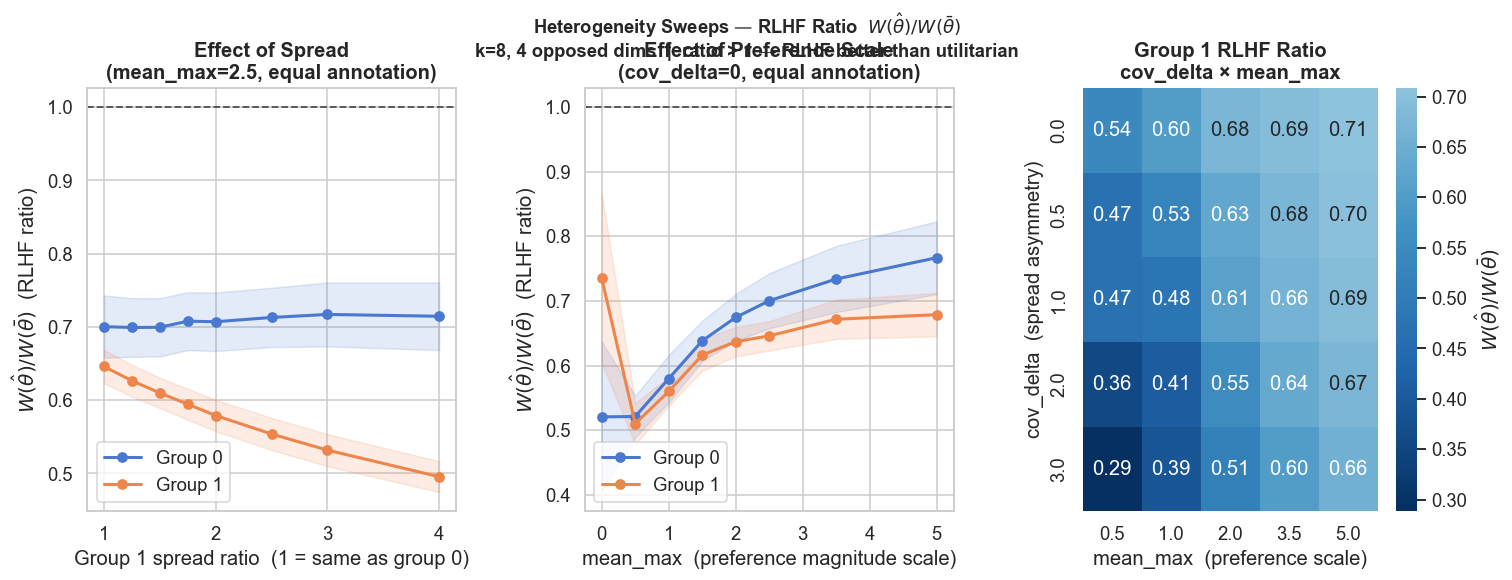

In [122]:
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Panel 1: Spread sweep ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
x = df_spread["spread_ratio"]

for g, (col, label) in enumerate([(colors[0], "Group 0"), (colors[1], "Group 1")]):
    mean_col = f"rlhf_ratio_g{g}_mean"
    se_col   = f"rlhf_ratio_g{g}_se"
    ax1.plot(x, df_spread[mean_col], 'o-', color=col, linewidth=2, label=label)
    ax1.fill_between(x,
                     df_spread[mean_col] - df_spread[se_col],
                     df_spread[mean_col] + df_spread[se_col],
                     alpha=0.15, color=col)

ax1.axhline(1.0, color='k', linewidth=1.2, linestyle='--', alpha=0.7)
ax1.set_xlabel("Group 1 spread ratio  (1 = same as group 0)")
ax1.set_ylabel(r"$W(\hat{\theta}) / W(\bar{\theta})$  (RLHF ratio)")
ax1.set_title("Effect of Spread\n(mean_max=2.5, equal annotation)", fontweight='bold')
ax1.legend()

# ── Panel 2: Mean scale sweep ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
x2  = df_scale["mean_max"]

for g, (col, label) in enumerate([(colors[0], "Group 0"), (colors[1], "Group 1")]):
    mean_col = f"rlhf_ratio_g{g}_mean"
    se_col   = f"rlhf_ratio_g{g}_se"
    ax2.plot(x2, df_scale[mean_col], 'o-', color=col, linewidth=2, label=label)
    ax2.fill_between(x2,
                     df_scale[mean_col] - df_scale[se_col],
                     df_scale[mean_col] + df_scale[se_col],
                     alpha=0.15, color=col)

ax2.axhline(1.0, color='k', linewidth=1.2, linestyle='--', alpha=0.7)
ax2.set_xlabel("mean_max  (preference magnitude scale)")
ax2.set_ylabel(r"$W(\hat{\theta}) / W(\bar{\theta})$  (RLHF ratio)")
ax2.set_title("Effect of Preference Scale\n(cov_delta=0, equal annotation)", fontweight='bold')
ax2.legend()

# ── Panel 3: Heatmap  cov_delta × mean_max → group 1 ratio ───────────────
ax3 = fig.add_subplot(gs[2])
heat_pivot = df_heat.pivot(index="cov_delta", columns="mean_max", values="rlhf_ratio_g1")
sns.heatmap(heat_pivot, ax=ax3, annot=True, fmt=".2f", cmap="RdBu_r",
            center=1.0, cbar_kws={"label": r"$W(\hat\theta)/W(\bar\theta)$"})
ax3.set_title("Group 1 RLHF Ratio\ncov_delta × mean_max", fontweight='bold')
ax3.set_ylabel("cov_delta  (spread asymmetry)")
ax3.set_xlabel("mean_max  (preference scale)")

plt.suptitle(
    r"Heterogeneity Sweeps — RLHF Ratio  $W(\hat\theta) / W(\bar\theta)$"
    "\nk=8, 4 opposed dims  |  ratio > 1 → RLHF better than utilitarian",
    fontweight="bold", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Sweeping Group Disagreement: 0 → k Opposed Dimensions

Fix equal groups, equal annotation, equal spread (`cov_delta=0`). Vary how many
dimensions are *opposed* (group 0 positive, group 1 negative) vs *aligned* (both positive).

**Key quantities to watch:**
- `rlhf_distortion` = W(θ̄) − W(θ̂): extra cost from RLHF vs. utilitarian optimum
- `delegation_loss` = W* − W(θ̄): unavoidable cost of delegating to *any* model
- `total_loss` = W* − W(θ̂): full welfare cost

At **0 opposed dims** (fully aligned): both groups want the same things — θ̄ is large and
shared, delegation loss is low, distortion is low.

At **k opposed dims** (fully opposed): θ̄ ≈ 0 (groups cancel). Both groups suffer
high delegation loss. But θ̂ ≈ θ̄ ≈ 0, so *distortion stays low* — RLHF finds
the utilitarian answer, it's just that the utilitarian answer is bad for everyone.


In [123]:
def sweep_disagreement(k=8, mean_magnitude=1.5, n_seeds=8, **dgp_overrides) -> pd.DataFrame:
    """
    Sweep number of opposed dimensions from 0 (fully aligned) to k (fully opposed).
    First n_opp dims are opposed (-1), remaining are aligned (+1).
    Averaged over n_seeds to reduce orientation noise.
    Pass extra DGPConfig fields via dgp_overrides (e.g., query_type="powerlaw").
    """
    records = []
    for n_opp in range(k + 1):
        agreement = np.array([-1]*n_opp + [+1]*(k - n_opp), dtype=float)
        rows = {col: [] for col in [
            'rlhf_ratio_g0', 'rlhf_ratio_g1',
            'deleg_ratio_g0', 'deleg_ratio_g1',
            'total_ratio_g0', 'total_ratio_g1',
            'W_ideal_g0', 'W_ideal_g1',
            'W_opt_g0', 'W_opt_g1',
            'W_rlhf_g0', 'W_rlhf_g1',
            'sw_gap', 'theta_dist',
        ]}
        for seed in range(n_seeds):
            cfg = DGPConfig(
                n_agents=50, k_dim=k,
                n_train_queries=1000, n_deploy_queries=200,
                n_groups=2,
                mean_magnitude=mean_magnitude,
                dim_agreement=agreement,
                cov_delta=0.0,
                seed=seed,
                **dgp_overrides,
            )
            res = Experiment(cfg).run()
            wdf = res['welfare_df']
            for g in range(2):
                gdf = wdf[wdf.group == g]
                w_rlhf, w_opt, w_ideal = gdf['W_rlhf'].mean(), gdf['W_opt'].mean(), gdf['W_ideal'].mean()
                rows[f'W_ideal_g{g}'].append(w_ideal)
                rows[f'W_opt_g{g}'].append(w_opt)
                rows[f'W_rlhf_g{g}'].append(w_rlhf)
                rows[f'rlhf_ratio_g{g}'].append(w_rlhf / w_opt if abs(w_opt) > 1e-10 else np.nan)
                rows[f'deleg_ratio_g{g}'].append(w_opt / w_ideal if abs(w_ideal) > 1e-10 else np.nan)
                rows[f'total_ratio_g{g}'].append(w_rlhf / w_ideal if abs(w_ideal) > 1e-10 else np.nan)
            rows['sw_gap'].append(res['sw_gap'])
            rows['theta_dist'].append(res['theta_dist'])

        records.append({
            'n_opposed':    n_opp,
            'frac_opposed': n_opp / k,
            **{col: np.nanmean(vals) for col, vals in rows.items()},
            **{col + '_se': np.nanstd(vals) / np.sqrt(n_seeds) for col, vals in rows.items()},
        })
    return pd.DataFrame(records)


print("Running disagreement sweep (Gaussian queries)...")
df_disagree = sweep_disagreement(k=8, n_seeds=8)
print("Done.")

Running disagreement sweep (Gaussian queries)...
Done.


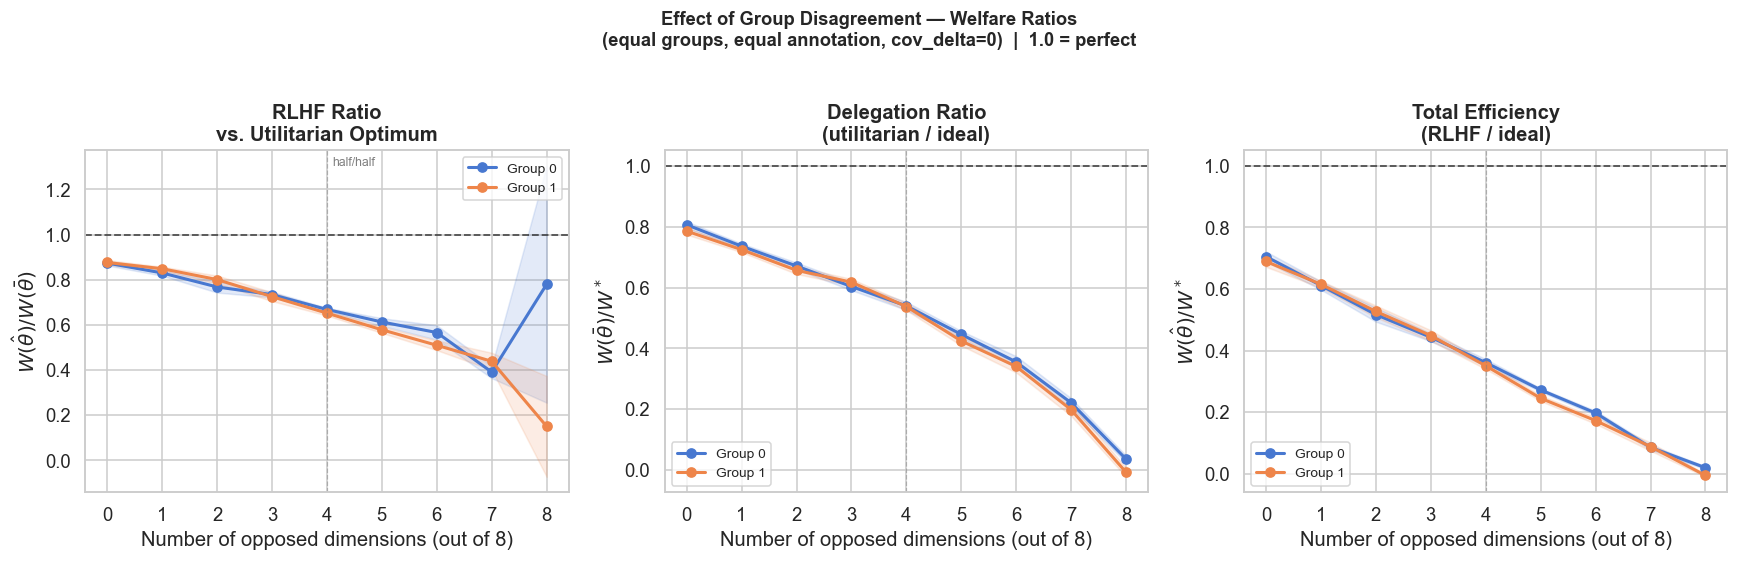

In [124]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x  = df_disagree['n_opposed']
c0, c1 = colors[0], colors[1]

# ── Panel 1: RLHF ratio ───────────────────────────────────────────────────
ax = axes[0]
for g, (col, label) in enumerate([(c0, 'Group 0'), (c1, 'Group 1')]):
    m, se = df_disagree[f'rlhf_ratio_g{g}'], df_disagree[f'rlhf_ratio_g{g}_se']
    ax.plot(x, m, 'o-', color=col, linewidth=2, label=label)
    ax.fill_between(x, m - se, m + se, alpha=0.15, color=col)
ax.axhline(1.0, color='k', linewidth=1.2, linestyle='--', alpha=0.7)
ax.axvline(4, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.text(4.1, ax.get_ylim()[1] * 0.95, 'half/half', fontsize=8, color='gray')
ax.set_xlabel('Number of opposed dimensions (out of 8)')
ax.set_ylabel(r'$W(\hat\theta) / W(\bar\theta)$')
ax.set_title('RLHF Ratio\nvs. Utilitarian Optimum', fontweight='bold')
ax.set_xticks(range(9))
ax.legend(fontsize=9)

# ── Panel 2: Delegation ratio ─────────────────────────────────────────────
ax = axes[1]
for g, (col, label) in enumerate([(c0, 'Group 0'), (c1, 'Group 1')]):
    m, se = df_disagree[f'deleg_ratio_g{g}'], df_disagree[f'deleg_ratio_g{g}_se']
    ax.plot(x, m, 'o-', color=col, linewidth=2, label=label)
    ax.fill_between(x, m - se, m + se, alpha=0.15, color=col)
ax.axhline(1.0, color='k', linewidth=1.2, linestyle='--', alpha=0.7)
ax.axvline(4, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Number of opposed dimensions (out of 8)')
ax.set_ylabel(r'$W(\bar\theta) / W^*$')
ax.set_title('Delegation Ratio\n(utilitarian / ideal)', fontweight='bold')
ax.set_xticks(range(9))
ax.legend(fontsize=9)

# ── Panel 3: Total ratio ──────────────────────────────────────────────────
ax = axes[2]
for g, (col, label) in enumerate([(c0, 'Group 0'), (c1, 'Group 1')]):
    m, se = df_disagree[f'total_ratio_g{g}'], df_disagree[f'total_ratio_g{g}_se']
    ax.plot(x, m, 'o-', color=col, linewidth=2, label=label)
    ax.fill_between(x, m - se, m + se, alpha=0.15, color=col)
ax.axhline(1.0, color='k', linewidth=1.2, linestyle='--', alpha=0.7)
ax.axvline(4, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Number of opposed dimensions (out of 8)')
ax.set_ylabel(r'$W(\hat\theta) / W^*$')
ax.set_title('Total Efficiency\n(RLHF / ideal)', fontweight='bold')
ax.set_xticks(range(9))
ax.legend(fontsize=9)

plt.suptitle('Effect of Group Disagreement — Welfare Ratios\n'
             '(equal groups, equal annotation, cov_delta=0)  |  1.0 = perfect',
             fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Welfare levels by disagreement regime (averaged over 8 seeds)
n_opp    W*_g0   W̄_g0    Ŵ_g0    W*_g1   W̄_g1    Ŵ_g1   W*_avg  W̄_avg   Ŵ_avg
------------------------------------------------------------------------------------------
    0    4.021   3.243   2.837    3.993   3.135   2.752    4.007   3.189   2.794
    1    4.021   2.960   2.459    4.010   2.903   2.466    4.016   2.931   2.463
    2    4.021   2.700   2.079    4.036   2.649   2.122    4.029   2.674   2.101
    3    4.021   2.429   1.785    4.121   2.544   1.846    4.071   2.487   1.816
    4    4.021   2.174   1.455    4.063   2.186   1.425    4.042   2.180   1.440
    5    4.021   1.792   1.095    4.084   1.741   1.004    4.053   1.767   1.050
    6    4.021   1.427   0.791    4.067   1.389   0.701    4.044   1.408   0.746
    7    4.021   0.889   0.344    4.079   0.814   0.362    4.050   0.851   0.353
    8    4.021   0.141   0.078    4.040  -0.022  -0.022    4.031   0.060   0.028


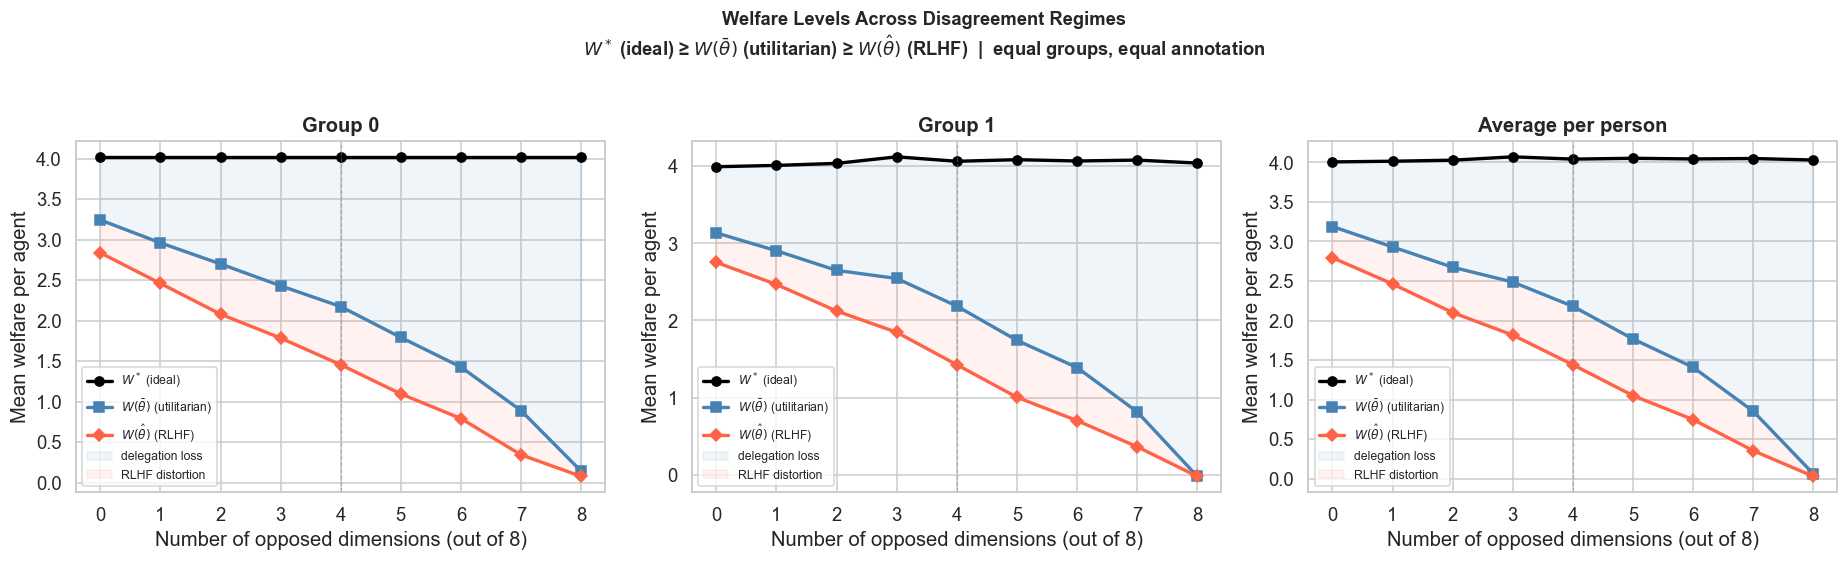

In [125]:
# ── Welfare Levels Table: W*, W(θ̄), W(θ̂) by group and disagreement ──────
# Compute average per-person welfare (equal weight to each individual)
df_d = df_disagree.copy()
df_d['W_ideal_avg'] = (df_d['W_ideal_g0'] + df_d['W_ideal_g1']) / 2
df_d['W_opt_avg']   = (df_d['W_opt_g0']   + df_d['W_opt_g1'])   / 2
df_d['W_rlhf_avg']  = (df_d['W_rlhf_g0']  + df_d['W_rlhf_g1'])  / 2

# Print table
print("Welfare levels by disagreement regime (averaged over 8 seeds)")
print("=" * 90)
header = f"{'n_opp':>5}  {'W*_g0':>7} {'W̄_g0':>7} {'Ŵ_g0':>7}  {'W*_g1':>7} {'W̄_g1':>7} {'Ŵ_g1':>7}  {'W*_avg':>7} {'W̄_avg':>7} {'Ŵ_avg':>7}"
print(header)
print("-" * 90)
for _, r in df_d.iterrows():
    print(f"{int(r['n_opposed']):>5}  "
          f"{r['W_ideal_g0']:>7.3f} {r['W_opt_g0']:>7.3f} {r['W_rlhf_g0']:>7.3f}  "
          f"{r['W_ideal_g1']:>7.3f} {r['W_opt_g1']:>7.3f} {r['W_rlhf_g1']:>7.3f}  "
          f"{r['W_ideal_avg']:>7.3f} {r['W_opt_avg']:>7.3f} {r['W_rlhf_avg']:>7.3f}")

# ── Chart: Welfare levels across disagreement regimes ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
x = df_d['n_opposed']
c0, c1 = colors[0], colors[1]

titles  = ['Group 0', 'Group 1', 'Average per person']
suffixes = ['_g0', '_g1', '_avg']

for ax, title, suf in zip(axes, titles, suffixes):
    ax.plot(x, df_d[f'W_ideal{suf}'], 'o-', color='black',   linewidth=2.2, label=r'$W^*$ (ideal)')
    ax.plot(x, df_d[f'W_opt{suf}'],   's-', color='steelblue', linewidth=2.2, label=r'$W(\bar\theta)$ (utilitarian)')
    ax.plot(x, df_d[f'W_rlhf{suf}'],  'D-', color='tomato',   linewidth=2.2, label=r'$W(\hat\theta)$ (RLHF)')

    # Shade the gaps
    ax.fill_between(x, df_d[f'W_opt{suf}'], df_d[f'W_ideal{suf}'],
                    alpha=0.08, color='steelblue', label='delegation loss')
    ax.fill_between(x, df_d[f'W_rlhf{suf}'], df_d[f'W_opt{suf}'],
                    alpha=0.08, color='tomato', label='RLHF distortion')

    ax.axvline(4, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel('Number of opposed dimensions (out of 8)')
    ax.set_ylabel('Mean welfare per agent')
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(9))
    ax.legend(fontsize=8, loc='lower left')

plt.suptitle(
    'Welfare Levels Across Disagreement Regimes\n'
    r'$W^*$ (ideal) ≥ $W(\bar\theta)$ (utilitarian) ≥ $W(\hat\theta)$ (RLHF)'
    '  |  equal groups, equal annotation',
    fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Running disagreement sweep (power-law queries, uniform topics)...
Done.


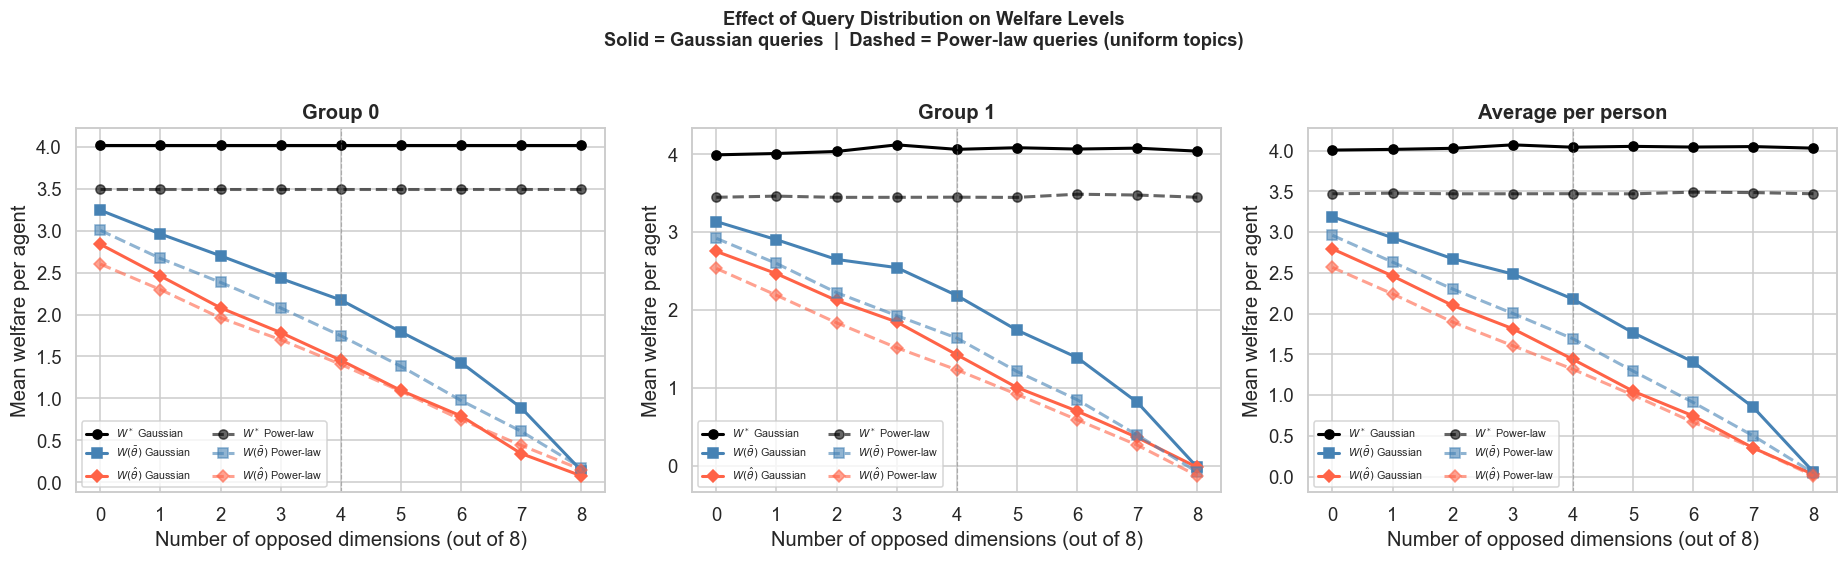



Welfare comparison: Gaussian vs Power-Law queries
n_opp       --- Gaussian ---             --- Power-Law ---           --- Δ (PL − G) ---     
            W*   W(θ̄)   W(θ̂)       W*   W(θ̄)   W(θ̂)      ΔW*  ΔW(θ̄)  ΔW(θ̂)
----------------------------------------------------------------------------------------------------
    0    4.007   3.189   2.794    3.471   2.961   2.567   -0.536  -0.227  -0.227
    1    4.016   2.931   2.463    3.478   2.633   2.243   -0.537  -0.298  -0.220
    2    4.029   2.674   2.101    3.471   2.303   1.897   -0.558  -0.372  -0.203
    3    4.071   2.487   1.816    3.471   2.003   1.607   -0.600  -0.484  -0.208
    4    4.042   2.180   1.440    3.472   1.693   1.318   -0.571  -0.487  -0.122
    5    4.053   1.767   1.050    3.470   1.296   1.001   -0.582  -0.470  -0.049
    6    4.044   1.408   0.746    3.491   0.912   0.669   -0.553  -0.497  -0.077
    7    4.050   0.851   0.353    3.486   0.501   0.353   -0.564  -0.351  +0.000
    8    4.031   0.060   

In [126]:
# ── Power-law queries: same disagreement sweep ────────────────────────────
k = 8
uniform_topics = np.ones(k) / k   # equal weight across all dimensions

print("Running disagreement sweep (power-law queries, uniform topics)...")
df_disagree_pl = sweep_disagreement(
    k=k, n_seeds=8,
    query_type="powerlaw",
    train_topic_weights=uniform_topics,
    deploy_topic_weights=uniform_topics,
)
print("Done.")

# ── Comparison chart: Gaussian vs Power-Law ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
x = df_disagree['n_opposed']

titles   = ['Group 0', 'Group 1', 'Average per person']
suffixes = ['_g0', '_g1', '_avg']

# Add average columns to power-law df
df_pl = df_disagree_pl.copy()
df_pl['W_ideal_avg'] = (df_pl['W_ideal_g0'] + df_pl['W_ideal_g1']) / 2
df_pl['W_opt_avg']   = (df_pl['W_opt_g0']   + df_pl['W_opt_g1'])   / 2
df_pl['W_rlhf_avg']  = (df_pl['W_rlhf_g0']  + df_pl['W_rlhf_g1'])  / 2

for ax, title, suf in zip(axes, titles, suffixes):
    # Gaussian (solid lines)
    ax.plot(x, df_d[f'W_ideal{suf}'], 'o-', color='black',     linewidth=2, label=r'$W^*$ Gaussian')
    ax.plot(x, df_d[f'W_opt{suf}'],   's-', color='steelblue',  linewidth=2, label=r'$W(\bar\theta)$ Gaussian')
    ax.plot(x, df_d[f'W_rlhf{suf}'],  'D-', color='tomato',     linewidth=2, label=r'$W(\hat\theta)$ Gaussian')

    # Power-law (dashed lines)
    ax.plot(x, df_pl[f'W_ideal{suf}'], 'o--', color='black',     linewidth=2, alpha=0.6, label=r'$W^*$ Power-law')
    ax.plot(x, df_pl[f'W_opt{suf}'],   's--', color='steelblue',  linewidth=2, alpha=0.6, label=r'$W(\bar\theta)$ Power-law')
    ax.plot(x, df_pl[f'W_rlhf{suf}'],  'D--', color='tomato',     linewidth=2, alpha=0.6, label=r'$W(\hat\theta)$ Power-law')

    ax.axvline(4, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel('Number of opposed dimensions (out of 8)')
    ax.set_ylabel('Mean welfare per agent')
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(9))
    ax.legend(fontsize=7, loc='lower left', ncol=2)

plt.suptitle(
    'Effect of Query Distribution on Welfare Levels\n'
    'Solid = Gaussian queries  |  Dashed = Power-law queries (uniform topics)',
    fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# ── Print comparison table ────────────────────────────────────────────────
print("\n\nWelfare comparison: Gaussian vs Power-Law queries")
print("=" * 100)
print(f"{'n_opp':>5}  {'--- Gaussian ---':^27}  {'--- Power-Law ---':^27}  {'--- Δ (PL − G) ---':^27}")
print(f"{'':>5}  {'W*':>7} {'W(θ̄)':>7} {'W(θ̂)':>7}  {'W*':>7} {'W(θ̄)':>7} {'W(θ̂)':>7}  {'ΔW*':>7} {'ΔW(θ̄)':>7} {'ΔW(θ̂)':>7}")
print("-" * 100)
for i in range(len(df_d)):
    g, p = df_d.iloc[i], df_pl.iloc[i]
    print(f"{int(g['n_opposed']):>5}  "
          f"{g['W_ideal_avg']:>7.3f} {g['W_opt_avg']:>7.3f} {g['W_rlhf_avg']:>7.3f}  "
          f"{p['W_ideal_avg']:>7.3f} {p['W_opt_avg']:>7.3f} {p['W_rlhf_avg']:>7.3f}  "
          f"{p['W_ideal_avg']-g['W_ideal_avg']:>+7.3f} "
          f"{p['W_opt_avg']-g['W_opt_avg']:>+7.3f} "
          f"{p['W_rlhf_avg']-g['W_rlhf_avg']:>+7.3f}")

---
## 10. Pool Composition × Disagreement: When Does Utilitarianism Hurt Minorities?

**Motivation:** Lever 2 revealed a counterintuitive result — when one group is a large majority,
*they* bear more RLHF distortion than the minority.  The mechanism: the utilitarian optimum
θ̄ faithfully reflects population proportions (80% majority → θ̄ ≈ majority preferences), while
the anonymous RLHF estimator θ̂ fails to perfectly implement that weighting due to the
nonlinearity of pooled logistic regression.  For the minority, W(θ̄) − W(θ̂) < 0 — the
utilitarian benchmark is actually *worse* for them than RLHF.

**Question:** Does this effect depend on how much groups disagree?

- **n_sep_dims = 0** (fully aligned): no conflict → θ̄ ≈ θ̂ for all pool splits → distortion ≈ 0
- **n_sep_dims = k** (fully opposed): strong conflict → θ̄ strongly biases toward majority →
  RLHF incidentally helps the minority more than the utilitarian optimum does

We sweep both dimensions jointly to map out the region where RLHF distortion flips sign.

In [127]:
def sweep_pool_x_disagreement(
    sep_dims_list=None, group0_fracs=None, n_seeds=8
) -> pd.DataFrame:
    """
    2D sweep: pool composition (group0_pool_frac) × intergroup disagreement (n_sep_dims).

    For each (n_sep_dims, pool_frac) pair, runs n_seeds experiments and records
    mean ± SE per-group RLHF distortion W(θ̄) − W(θ̂).

    Key question: for what combinations does minority distortion go negative
    (i.e. RLHF incidentally outperforms the utilitarian optimum for the minority)?
    """
    sep_dims_list = sep_dims_list if sep_dims_list is not None else list(range(9))  # 0..8
    group0_fracs  = group0_fracs  or [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    N = 200
    records = []
    total = len(sep_dims_list) * len(group0_fracs)
    done  = 0
    for nd in sep_dims_list:
        for f0 in group0_fracs:
            n0   = max(1, round(N * f0))
            r0s, r1s, tr0s, tr1s = [], [], [], []
            for seed in range(n_seeds):
                cfg = DGPConfig(
                    **_base_cfg(n_sep_dims=nd, seed=seed),
                    group_sizes=[n0, N - n0],
                )
                res = Experiment(cfg).run()
                wdf = res["welfare_df"]
                for g, (rl, trl) in enumerate([(r0s, tr0s), (r1s, tr1s)]):
                    gdf = wdf[wdf.group == g]
                    w_rlhf, w_opt, w_ideal = gdf["W_rlhf"].mean(), gdf["W_opt"].mean(), gdf["W_ideal"].mean()
                    rl.append(w_rlhf / w_opt if abs(w_opt) > 1e-10 else np.nan)
                    trl.append(w_rlhf / w_ideal if abs(w_ideal) > 1e-10 else np.nan)
            records.append({
                "n_sep_dims":         nd,
                "group0_pool_frac":   f0,
                "rlhf_ratio_g0_mean": np.nanmean(r0s),
                "rlhf_ratio_g0_se":   np.nanstd(r0s) / np.sqrt(n_seeds),
                "rlhf_ratio_g1_mean": np.nanmean(r1s),
                "rlhf_ratio_g1_se":   np.nanstd(r1s) / np.sqrt(n_seeds),
                "total_ratio_g0_mean": np.nanmean(tr0s),
                "total_ratio_g0_se":   np.nanstd(tr0s) / np.sqrt(n_seeds),
                "total_ratio_g1_mean": np.nanmean(tr1s),
                "total_ratio_g1_se":   np.nanstd(tr1s) / np.sqrt(n_seeds),
            })
            done += 1
            if done % 9 == 0:
                print(f"  {done}/{total} cells done (n_sep_dims={nd})")
    return pd.DataFrame(records)


print("Running pool × disagreement sweep (9 × 9 grid, 8 seeds each)...")
df_pool_disagree = sweep_pool_x_disagreement()
print("Done.")

Running pool × disagreement sweep (9 × 9 grid, 8 seeds each)...
  9/81 cells done (n_sep_dims=0)
  18/81 cells done (n_sep_dims=1)
  27/81 cells done (n_sep_dims=2)
  36/81 cells done (n_sep_dims=3)
  45/81 cells done (n_sep_dims=4)
  54/81 cells done (n_sep_dims=5)
  63/81 cells done (n_sep_dims=6)
  72/81 cells done (n_sep_dims=7)
  81/81 cells done (n_sep_dims=8)
Done.


/var/folders/yr/f3z1jw3j2390b9qngzcf_8mh0000gn/T/ipykernel_45639/1919387590.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


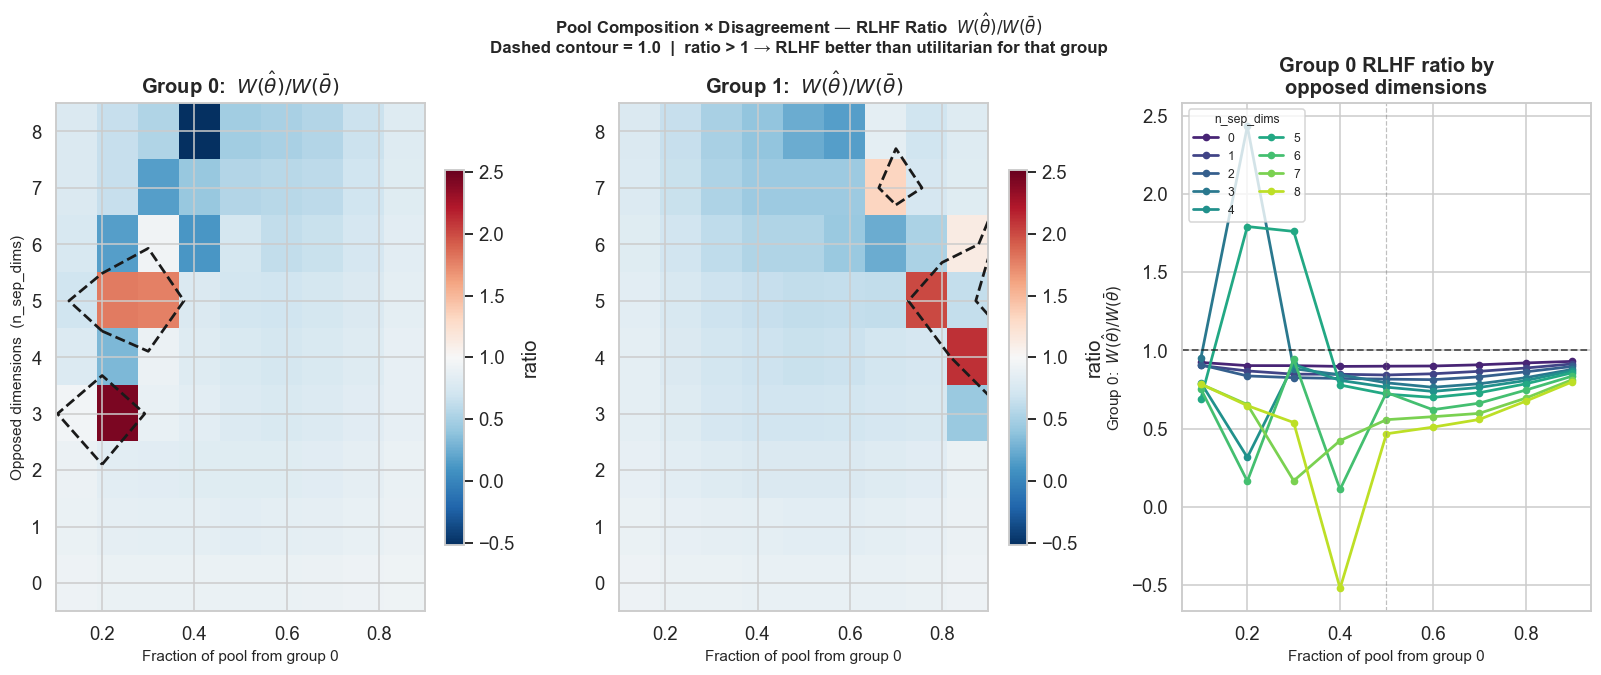

In [128]:
fig = plt.figure(figsize=(18, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

fracs   = sorted(df_pool_disagree["group0_pool_frac"].unique())
sep_dims = sorted(df_pool_disagree["n_sep_dims"].unique())

def _pivot(col):
    return (df_pool_disagree
            .pivot(index="n_sep_dims", columns="group0_pool_frac", values=col)
            .reindex(index=sep_dims, columns=fracs))

g0_mat = _pivot("rlhf_ratio_g0_mean").values
g1_mat = _pivot("rlhf_ratio_g1_mean").values

# Diverging colormap centered at 1.0
vdiff = max(np.abs(g0_mat - 1).max(), np.abs(g1_mat - 1).max())
cmap = "RdBu_r"  # red > 1 (RLHF better), blue < 1 (RLHF worse)

# ── Panel 1: Group 0 RLHF ratio heatmap ─────────────────────────────────
ax0 = fig.add_subplot(gs[0])
im0 = ax0.imshow(g0_mat, aspect="auto", origin="lower",
                  cmap=cmap, vmin=1-vdiff, vmax=1+vdiff,
                  extent=[fracs[0], fracs[-1], sep_dims[0] - 0.5, sep_dims[-1] + 0.5])
ax0.contour(np.array(fracs), np.array(sep_dims), g0_mat,
            levels=[1.0], colors='k', linewidths=1.8, linestyles='--')
ax0.set_xlabel("Fraction of pool from group 0", fontsize=10)
ax0.set_ylabel("Opposed dimensions  (n_sep_dims)", fontsize=10)
ax0.set_title(r"Group 0:  $W(\hat\theta) / W(\bar\theta)$", fontweight="bold")
ax0.set_yticks(sep_dims)
plt.colorbar(im0, ax=ax0, fraction=0.046, label="ratio")

# ── Panel 2: Group 1 RLHF ratio heatmap ─────────────────────────────────
ax1 = fig.add_subplot(gs[1])
im1 = ax1.imshow(g1_mat, aspect="auto", origin="lower",
                  cmap=cmap, vmin=1-vdiff, vmax=1+vdiff,
                  extent=[fracs[0], fracs[-1], sep_dims[0] - 0.5, sep_dims[-1] + 0.5])
ax1.contour(np.array(fracs), np.array(sep_dims), g1_mat,
            levels=[1.0], colors='k', linewidths=1.8, linestyles='--')
ax1.set_xlabel("Fraction of pool from group 0", fontsize=10)
ax1.set_title(r"Group 1:  $W(\hat\theta) / W(\bar\theta)$", fontweight="bold")
ax1.set_yticks(sep_dims)
plt.colorbar(im1, ax=ax1, fraction=0.046, label="ratio")

# ── Panel 3: Line plot — group 0 RLHF ratio by n_sep_dims ────────────────
ax2 = fig.add_subplot(gs[2])
palette = plt.cm.viridis(np.linspace(0.1, 0.9, len(sep_dims)))
for nd, color in zip(sep_dims, palette):
    sub = df_pool_disagree[df_pool_disagree.n_sep_dims == nd].sort_values("group0_pool_frac")
    ax2.plot(sub["group0_pool_frac"], sub["rlhf_ratio_g0_mean"],
             'o-', color=color, linewidth=1.8, markersize=4, label=f"{nd}")
ax2.axhline(1.0, color='k', linewidth=1.2, linestyle='--', alpha=0.7)
ax2.axvline(0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax2.set_xlabel("Fraction of pool from group 0", fontsize=10)
ax2.set_ylabel(r"Group 0:  $W(\hat\theta) / W(\bar\theta)$", fontsize=10)
ax2.set_title("Group 0 RLHF ratio by\nopposed dimensions", fontweight="bold")
ax2.legend(title="n_sep_dims", fontsize=8, title_fontsize=8,
           loc="upper left", ncol=2)

plt.suptitle(
    r"Pool Composition × Disagreement — RLHF Ratio  $W(\hat\theta) / W(\bar\theta)$"
    "\nDashed contour = 1.0  |  ratio > 1 → RLHF better than utilitarian for that group",
    fontweight="bold", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

/var/folders/yr/f3z1jw3j2390b9qngzcf_8mh0000gn/T/ipykernel_45639/312068357.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


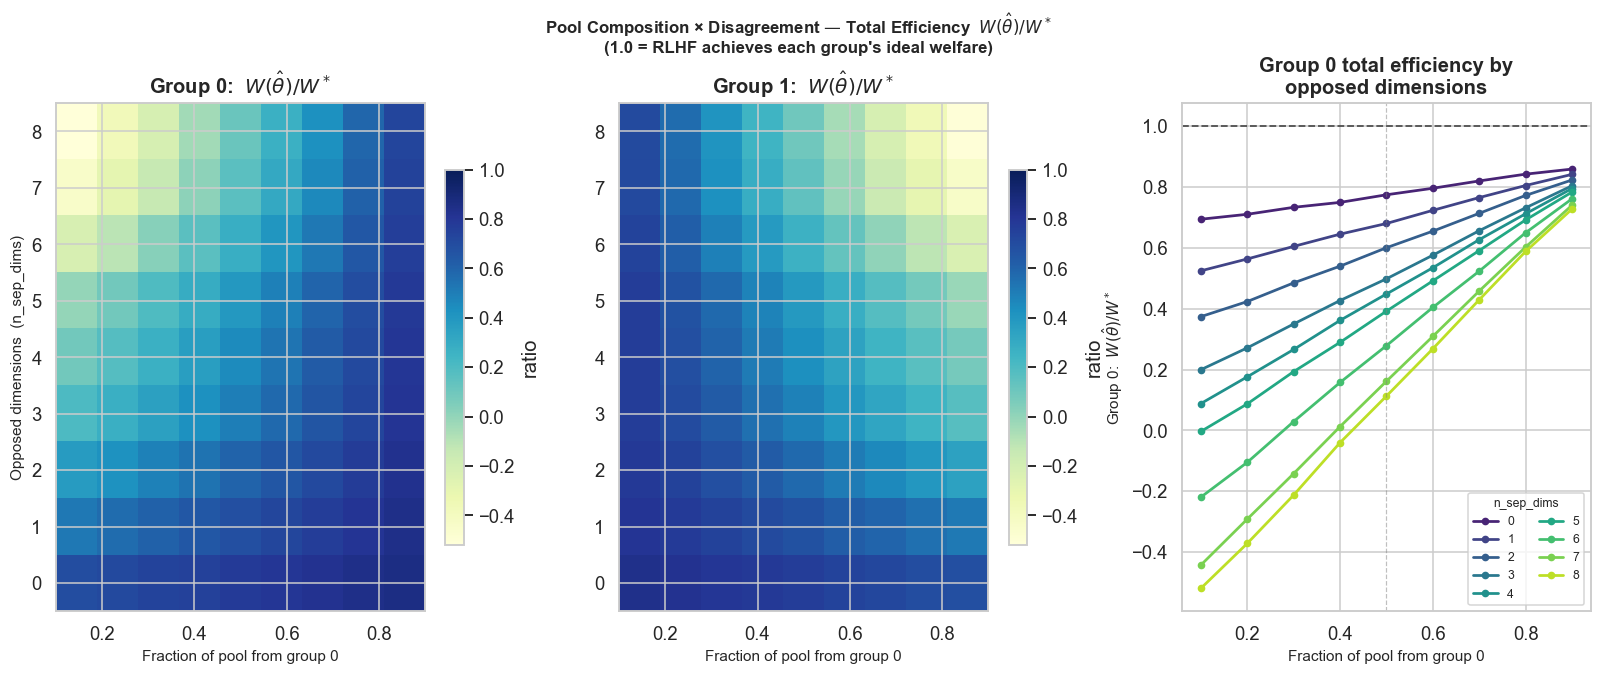

In [129]:
# ── Pool × Disagreement: Total Efficiency Ratio  W(θ̂)/W* ────────────────
fig = plt.figure(figsize=(18, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

fracs    = sorted(df_pool_disagree["group0_pool_frac"].unique())
sep_dims = sorted(df_pool_disagree["n_sep_dims"].unique())

def _pivot_tr(col):
    return (df_pool_disagree
            .pivot(index="n_sep_dims", columns="group0_pool_frac", values=col)
            .reindex(index=sep_dims, columns=fracs))

g0_tr = _pivot_tr("total_ratio_g0_mean").values
g1_tr = _pivot_tr("total_ratio_g1_mean").values

vmin_tr = min(g0_tr.min(), g1_tr.min())

# ── Panel 1: Group 0 total ratio heatmap ─────────────────────────────────
ax0 = fig.add_subplot(gs[0])
im0 = ax0.imshow(g0_tr, aspect="auto", origin="lower",
                  cmap="YlGnBu", vmin=vmin_tr, vmax=1.0,
                  extent=[fracs[0], fracs[-1], sep_dims[0] - 0.5, sep_dims[-1] + 0.5])
ax0.set_xlabel("Fraction of pool from group 0", fontsize=10)
ax0.set_ylabel("Opposed dimensions  (n_sep_dims)", fontsize=10)
ax0.set_title(r"Group 0:  $W(\hat\theta) / W^*$", fontweight="bold")
ax0.set_yticks(sep_dims)
plt.colorbar(im0, ax=ax0, fraction=0.046, label="ratio")

# ── Panel 2: Group 1 total ratio heatmap ─────────────────────────────────
ax1 = fig.add_subplot(gs[1])
im1 = ax1.imshow(g1_tr, aspect="auto", origin="lower",
                  cmap="YlGnBu", vmin=vmin_tr, vmax=1.0,
                  extent=[fracs[0], fracs[-1], sep_dims[0] - 0.5, sep_dims[-1] + 0.5])
ax1.set_xlabel("Fraction of pool from group 0", fontsize=10)
ax1.set_title(r"Group 1:  $W(\hat\theta) / W^*$", fontweight="bold")
ax1.set_yticks(sep_dims)
plt.colorbar(im1, ax=ax1, fraction=0.046, label="ratio")

# ── Panel 3: Line plot — group 0 total ratio by n_sep_dims ───────────────
ax2 = fig.add_subplot(gs[2])
palette = plt.cm.viridis(np.linspace(0.1, 0.9, len(sep_dims)))
for nd, color in zip(sep_dims, palette):
    sub = df_pool_disagree[df_pool_disagree.n_sep_dims == nd].sort_values("group0_pool_frac")
    ax2.plot(sub["group0_pool_frac"], sub["total_ratio_g0_mean"],
             'o-', color=color, linewidth=1.8, markersize=4, label=f"{nd}")
ax2.axhline(1.0, color='k', linewidth=1.2, linestyle='--', alpha=0.7)
ax2.axvline(0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax2.set_xlabel("Fraction of pool from group 0", fontsize=10)
ax2.set_ylabel(r"Group 0:  $W(\hat\theta) / W^*$", fontsize=10)
ax2.set_title("Group 0 total efficiency by\nopposed dimensions", fontweight="bold")
ax2.legend(title="n_sep_dims", fontsize=8, title_fontsize=8,
           loc="lower right", ncol=2)

plt.suptitle(
    r"Pool Composition × Disagreement — Total Efficiency  $W(\hat\theta) / W^*$"
    "\n(1.0 = RLHF achieves each group's ideal welfare)",
    fontweight="bold", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

---
## 10. Realistic Scenario: Expert-Crowd Annotation Bias

We construct a concrete instance where $\hat\theta \gg \bar\theta$ using **three compounding distortions** grounded in realistic RLHF deployment:

| Distortion lever | Setup | Realistic analogue |
|---|---|---|
| **Annotation imbalance** | 80% crowd / 20% expert labels | Outsourced crowd labeling (Scale AI, Surge) overrepresents generalist annotators |
| **Training query bias** | Training dominated by safety & warmth queries | ML engineers curate "interesting/challenging" prompts that skew toward popular topics |
| **Train → deploy shift** | Deployment concentrated on technical queries | Real users submit specialized queries not well-represented in training curation |

### Groups and preference dimensions

We use **k = 4 interpretable dimensions** and **two groups** with opposed preferences on the key dimension (Technical Depth):

| Dimension | Group A: Crowd (60% of users, 80% of labels) | Group B: Experts (40% of users, 20% of labels) |
|---|---|---|
| 0 · Safety/Caution | **+2.0** (strong positive) | −0.5 |
| 1 · Technical Depth | **−0.5** | **+2.0** (strong positive) |
| 2 · Emotional Warmth | **+1.5** | +0.5 |
| 3 · Conciseness | **+1.0** | −1.0 |

Group A has **noisy preferences** (high within-group variance on Technical Depth, σ ≈ 1.9) — representing heterogeneous crowd workers who lack domain expertise to form consistent opinions about technical quality. Group B has **coherent preferences** (low variance on Technical Depth, σ ≈ 0.55) — domain experts who strongly agree on what good technical content looks like.

### Distributional assumptions

- **Preferences**: $\theta_n \sim \mathcal{N}(\mu_g, \Sigma_g)$ with **diagonal** $\Sigma_g$ — dimension-specific variances, no cross-dim correlations. This lets us say precisely *which* dimensions each group is uncertain about.
- **BTL choice model**: $y \sim \text{Bernoulli}(\sigma(\alpha_z^\top \theta_n))$ — log-odds linearity, no interaction effects.
- **Query distribution (power-law)**: Each query $\alpha_z$ has one *dominant dimension* drawn from a topic-weight distribution, with a Gamma-distributed magnitude. Background noise on other dims. This captures the skewed frequency of real query types (many routine queries, few specialized ones).
- **Training vs. deployment shift**: Training topics ≈ [Safety: 55%, Warmth: 35%, Technical: 5%, Conciseness: 5%]; Deployment topics ≈ [Technical: 50%, Safety: 15%, Warmth: 20%, Conciseness: 15%].
- **Social welfare**: Utilitarian, equal individual weights (1/N).


In [130]:
# ── Scenario constants ────────────────────────────────────────────────────
DIM_NAMES = ["Safety/Caution", "Technical Depth", "Emotional Warmth", "Conciseness"]

CROWD_MEAN  = np.array([ 2.0, -0.5,  1.5,  1.0])   # Group A: safety-focused, non-technical
EXPERT_MEAN = np.array([-0.5,  2.0,  0.5, -1.0])   # Group B: technical, verbose

# Per-dimension variances (diagonal covariance).
# Crowd: high variance on Technical Depth — they rarely evaluate technical content
#        and lack domain knowledge to form consistent opinions.
# Experts: low variance on Technical Depth — they strongly agree on what good
#          technical content looks like.
CROWD_VARS  = np.array([0.8, 3.5, 1.0, 0.8])   # uncertain on dim 1 (technical)
EXPERT_VARS = np.array([0.8, 0.3, 0.7, 0.5])   # coherent on dim 1 (technical)

# Training queries: power-law biased toward safety (dim 0) and warmth (dim 2)
TRAIN_TOPICS  = np.array([0.55, 0.05, 0.35, 0.05])
# Deployment queries: shifted toward technical depth (dim 1)
DEPLOY_TOPICS = np.array([0.15, 0.50, 0.20, 0.15])

realistic_cfg = DGPConfig(
    n_agents=50, k_dim=4,
    n_train_queries=1500, n_deploy_queries=500,
    n_groups=2,
    group_sizes=[30, 20],                        # 60% crowd, 40% experts
    seed=42,
    group_mean_vectors=[CROWD_MEAN, EXPERT_MEAN],
    group_dim_variances=[CROWD_VARS, EXPERT_VARS],  # diagonal, dim-specific noise
    train_group_fracs=[0.80, 0.20],              # 80% of training labels from crowd
    query_type="powerlaw",
    train_topic_weights=TRAIN_TOPICS,
    deploy_topic_weights=DEPLOY_TOPICS,
    query_scale=1.5,
)

realistic_exp = Experiment(realistic_cfg)
realistic_res = realistic_exp.run()

dgp_r  = realistic_exp.dgp
rlhf_r = realistic_exp.rlhf
welf_r = realistic_exp.welfare
wdf_r  = realistic_res["welfare_df"]

# ── Diagnostics ───────────────────────────────────────────────────────────
crowd_mean_emp  = dgp_r.theta[dgp_r.agent_groups == 0].mean(0)
expert_mean_emp = dgp_r.theta[dgp_r.agent_groups == 1].mean(0)

print(f"{'Dimension':<22} {'E[θ|crowd]':>12} {'E[θ|expert]':>12} {'θ̄':>8} {'θ̂':>8} {'gap(θ̂−θ̄)':>12}")
print("-" * 78)
for d, name in enumerate(DIM_NAMES):
    print(f"{name:<22} {crowd_mean_emp[d]:>12.3f} {expert_mean_emp[d]:>12.3f} "
          f"{realistic_res['theta_bar'][d]:>8.3f} {realistic_res['theta_hat'][d]:>8.3f} "
          f"{realistic_res['theta_hat'][d] - realistic_res['theta_bar'][d]:>12.3f}")

print(f"\n{'Dimension':<22} {'Crowd σ':>10} {'Expert σ':>10}   (std dev of θ_n within group)")
print("-" * 45)
for d, name in enumerate(DIM_NAMES):
    print(f"{name:<22} {np.sqrt(CROWD_VARS[d]):>10.2f} {np.sqrt(EXPERT_VARS[d]):>10.2f}")

print(f"\n||θ̂ − θ̄||₂                = {realistic_res['theta_dist']:.3f}")
print(f"Social welfare gap         = {realistic_res['sw_gap']:.4f}")
print(f"Crowd RLHF distortion      = {wdf_r[wdf_r.group==0]['rlhf_distortion'].mean():.4f}  (mean per agent)")
print(f"Expert RLHF distortion     = {wdf_r[wdf_r.group==1]['rlhf_distortion'].mean():.4f}  (mean per agent)")


Dimension                E[θ|crowd]  E[θ|expert]       θ̄       θ̂   gap(θ̂−θ̄)
------------------------------------------------------------------------------
Safety/Caution                1.997       -0.468    1.011    0.456       -0.555
Technical Depth              -0.908        1.986    0.249    0.014       -0.236
Emotional Warmth              1.326        0.551    1.016    0.463       -0.553
Conciseness                   1.137       -1.009    0.279    0.215       -0.064

Dimension                 Crowd σ   Expert σ   (std dev of θ_n within group)
---------------------------------------------
Safety/Caution               0.89       0.89
Technical Depth              1.87       0.55
Emotional Warmth             1.00       0.84
Conciseness                  0.89       0.71

||θ̂ − θ̄||₂                = 0.820
Social welfare gap         = 0.4218
Crowd RLHF distortion      = -0.1855  (mean per agent)
Expert RLHF distortion     = 1.3328  (mean per agent)


/Users/michellesi/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


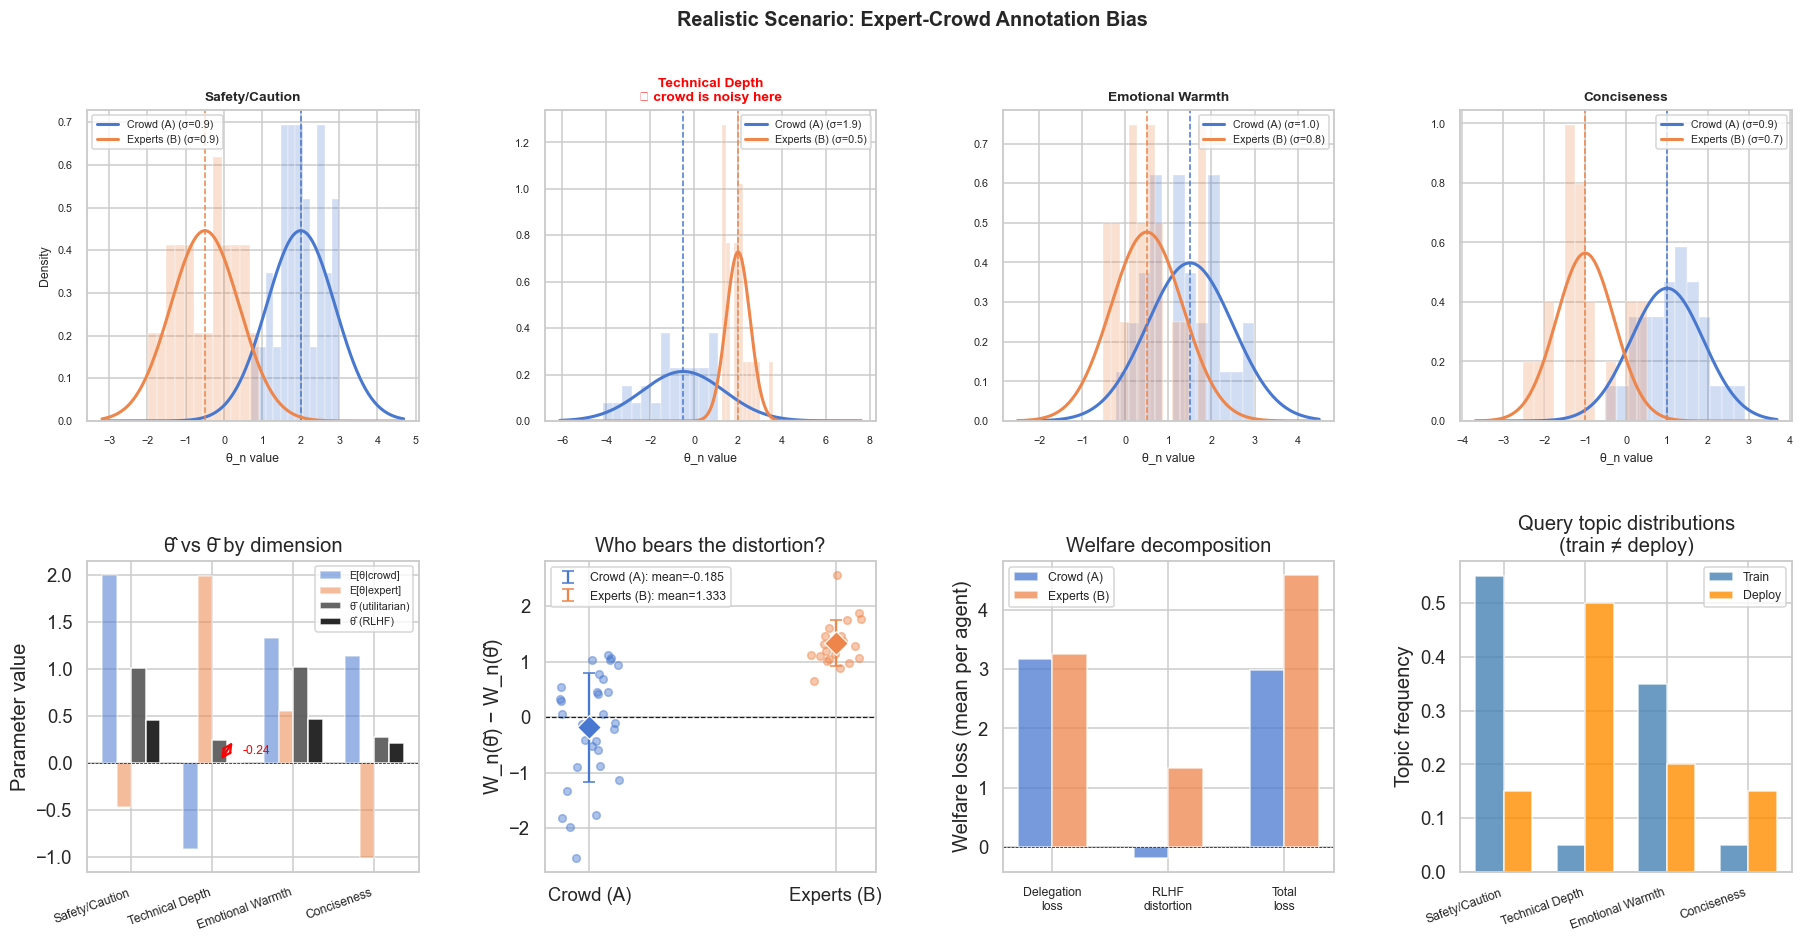

In [131]:
# ── Visualization ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 9))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle("Realistic Scenario: Expert-Crowd Annotation Bias", fontsize=13, fontweight='bold')

group_labels = ['Crowd (A)', 'Experts (B)']

# ── Top row, Panel 1: per-dimension marginal distributions ────────────────
# Shows the diagonal covariance structure — which dims each group is noisy on
for d, name in enumerate(DIM_NAMES):
    ax = fig.add_subplot(gs[0, d])
    for g, (label, color, mean, var) in enumerate(zip(
        group_labels, colors,
        [CROWD_MEAN, EXPERT_MEAN],
        [CROWD_VARS, EXPERT_VARS],
    )):
        samples = dgp_r.theta[dgp_r.agent_groups == g, d]
        xlo = min(CROWD_MEAN[d], EXPERT_MEAN[d]) - 3 * np.sqrt(max(CROWD_VARS[d], EXPERT_VARS[d]))
        xhi = max(CROWD_MEAN[d], EXPERT_MEAN[d]) + 3 * np.sqrt(max(CROWD_VARS[d], EXPERT_VARS[d]))
        xs  = np.linspace(xlo, xhi, 200)
        from scipy.stats import norm
        pdf = norm.pdf(xs, loc=mean[d], scale=np.sqrt(var[d]))
        ax.plot(xs, pdf, color=color, lw=2, label=f'{label} (σ={np.sqrt(var[d]):.1f})')
        ax.hist(samples, bins=12, density=True, color=color, alpha=0.25)
        ax.axvline(mean[d], color=color, ls='--', lw=1)
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('θ_n value', fontsize=8)
    ax.set_ylabel('Density' if d == 0 else '', fontsize=8)
    ax.tick_params(labelsize=7)
    if d == 1:  # Technical Depth — annotate the key story
        ax.set_title(f'{name}\n★ crowd is noisy here', fontsize=9, fontweight='bold', color='red')
    ax.legend(fontsize=7)

# ── Bottom row, Panel 1: θ̂ vs θ̄ vs group means ──────────────────────────
ax = fig.add_subplot(gs[1, 0])
x = np.arange(4)
w = 0.18
crowd_th  = dgp_r.theta[dgp_r.agent_groups == 0].mean(0)
expert_th = dgp_r.theta[dgp_r.agent_groups == 1].mean(0)
ax.bar(x - 1.5*w, crowd_th,                   w, label='E[θ|crowd]',       color=colors[0], alpha=0.55)
ax.bar(x - 0.5*w, expert_th,                  w, label='E[θ|expert]',      color=colors[1], alpha=0.55)
ax.bar(x + 0.5*w, realistic_res["theta_bar"],  w, label='θ̄ (utilitarian)', color='#555555', alpha=0.90)
ax.bar(x + 1.5*w, realistic_res["theta_hat"],  w, label='θ̂ (RLHF)',        color='#111111', alpha=0.90)
d1 = 1
gap = realistic_res["theta_hat"][d1] - realistic_res["theta_bar"][d1]
y_lo = min(realistic_res["theta_hat"][d1], realistic_res["theta_bar"][d1])
y_hi = max(realistic_res["theta_hat"][d1], realistic_res["theta_bar"][d1])
ax.annotate('', xy=(x[d1]+1.5*w, y_hi), xytext=(x[d1]+0.5*w, y_lo),
            arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))
ax.text(x[d1]+2.1*w, (y_lo+y_hi)/2, f'{gap:+.2f}', color='red', fontsize=8, va='center')
ax.set_xticks(x); ax.set_xticklabels(DIM_NAMES, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Parameter value'); ax.set_title('θ̂ vs θ̄ by dimension')
ax.axhline(0, color='k', lw=0.5, ls='--'); ax.legend(fontsize=7)

# ── Bottom row, Panel 2: per-agent RLHF distortion ───────────────────────
ax = fig.add_subplot(gs[1, 1])
rng_j = np.random.default_rng(0)
for g, (name, color) in enumerate(zip(group_labels, colors)):
    dist   = wdf_r[wdf_r.group == g]["rlhf_distortion"].values
    jitter = rng_j.uniform(-0.12, 0.12, size=len(dist))
    ax.scatter(np.full_like(dist, g) + jitter, dist, color=color, alpha=0.45, s=25)
    ax.scatter([g], [dist.mean()], color=color, s=120, marker='D',
               zorder=5, edgecolors='white', linewidths=0.8)
    ax.errorbar([g], [dist.mean()], yerr=[dist.std()],
                fmt='none', color=color, capsize=4, lw=1.5, label=f'{name}: mean={dist.mean():.3f}')
ax.set_xticks([0, 1]); ax.set_xticklabels(group_labels)
ax.set_ylabel('W_n(θ̄) − W_n(θ̂)'); ax.set_title('Who bears the distortion?')
ax.axhline(0, color='k', lw=0.8, ls='--'); ax.legend(fontsize=8)

# ── Bottom row, Panel 3: welfare decomposition ───────────────────────────
ax = fig.add_subplot(gs[1, 2])
metrics       = ['delegation_loss', 'rlhf_distortion', 'total_loss']
metric_labels = ['Delegation\nloss', 'RLHF\ndistortion', 'Total\nloss']
bar_w = 0.3
for gi, (name, color) in enumerate(zip(group_labels, colors)):
    sub  = wdf_r[wdf_r.group == gi]
    vals = [sub[m].mean() for m in metrics]
    xs   = np.arange(len(metrics)) + (gi - 0.5) * bar_w
    ax.bar(xs, vals, bar_w, color=color, alpha=0.75, label=name)
ax.set_xticks(np.arange(len(metrics))); ax.set_xticklabels(metric_labels, fontsize=8)
ax.set_ylabel('Welfare loss (mean per agent)'); ax.set_title('Welfare decomposition')
ax.axhline(0, color='k', lw=0.5, ls='--'); ax.legend(fontsize=8)

# ── Bottom row, Panel 4: query topic distributions ───────────────────────
ax = fig.add_subplot(gs[1, 3])
xpos  = np.arange(4)
bar_w = 0.35
ax.bar(xpos - bar_w/2, TRAIN_TOPICS  / TRAIN_TOPICS.sum(),  bar_w, label='Train',  color='steelblue', alpha=0.8)
ax.bar(xpos + bar_w/2, DEPLOY_TOPICS / DEPLOY_TOPICS.sum(), bar_w, label='Deploy', color='darkorange', alpha=0.8)
ax.set_xticks(xpos); ax.set_xticklabels(DIM_NAMES, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Topic frequency'); ax.set_title('Query topic distributions\n(train ≠ deploy)')
ax.legend(fontsize=8)

plt.show()


Running annotation fraction sweep (~30s)...
Done.


/var/folders/yr/f3z1jw3j2390b9qngzcf_8mh0000gn/T/ipykernel_45639/3927424055.py:90: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
/Users/michellesi/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


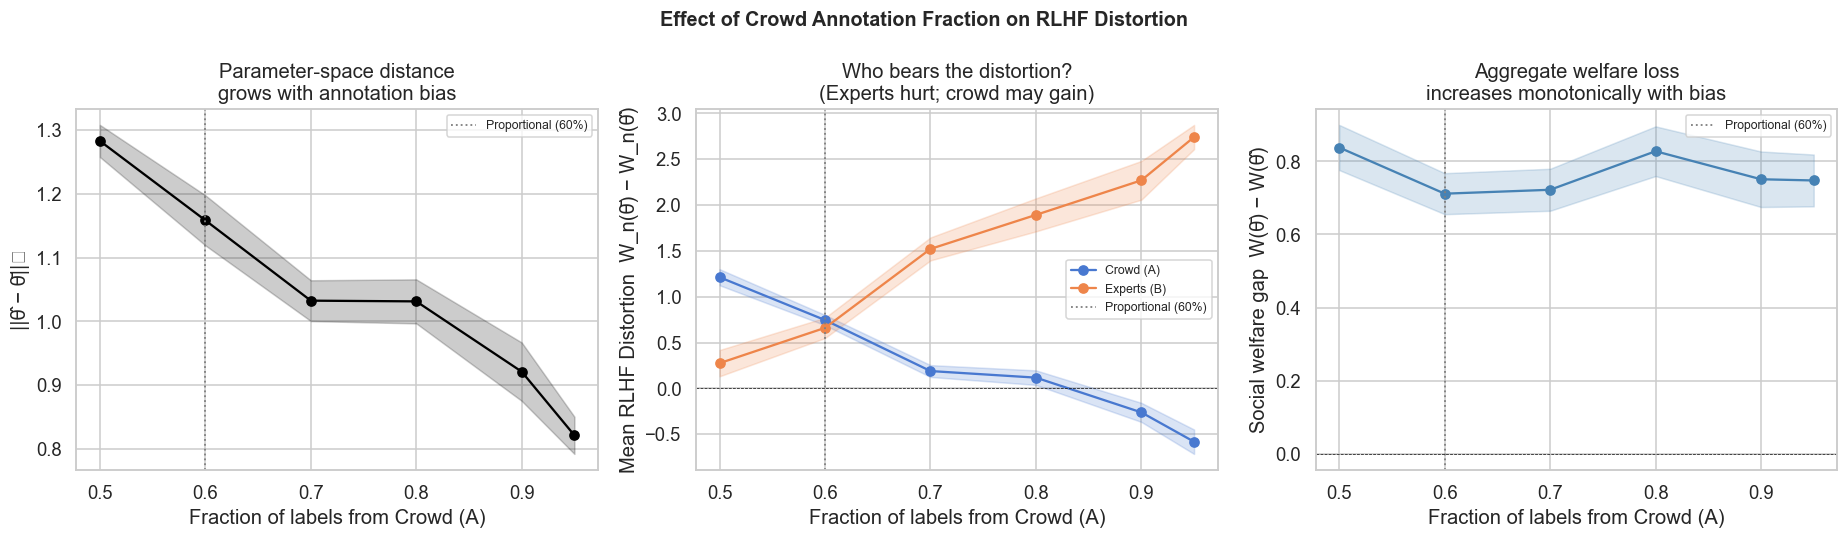

In [132]:
# ── Sweep: annotation fraction (% crowd labels) ───────────────────────────
def sweep_annotation_fraction(fracs=None, n_seeds=12) -> pd.DataFrame:
    """
    Sweep the fraction of training labels coming from crowd (Group A).
    Everything else held fixed: 60/40 population split, power-law queries,
    same diagonal covariances (crowd noisy on dim 1, experts coherent on dim 1).

    At frac=0.6 annotations are proportional to population share → no bias.
    At frac=0.9 crowd dominates → large θ̂−θ̄ gap.
    """
    fracs = fracs or [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]
    records = []
    for frac in fracs:
        for seed in range(n_seeds):
            cfg = DGPConfig(
                n_agents=50, k_dim=4,
                n_train_queries=1500, n_deploy_queries=500,
                n_groups=2,
                group_sizes=[30, 20],
                seed=seed * 97 + int(frac * 100),
                group_mean_vectors=[CROWD_MEAN, EXPERT_MEAN],
                group_dim_variances=[CROWD_VARS, EXPERT_VARS],
                train_group_fracs=[frac, 1.0 - frac],
                query_type="powerlaw",
                train_topic_weights=TRAIN_TOPICS,
                deploy_topic_weights=DEPLOY_TOPICS,
                query_scale=1.5,
            )
            res = Experiment(cfg).run()
            wdf = res["welfare_df"]
            records.append({
                "crowd_label_frac":  frac,
                "theta_dist":        res["theta_dist"],
                "sw_gap":            res["sw_gap"],
                "distortion_crowd":  wdf[wdf.group == 0]["rlhf_distortion"].mean(),
                "distortion_expert": wdf[wdf.group == 1]["rlhf_distortion"].mean(),
            })
    return pd.DataFrame(records)

print("Running annotation fraction sweep (~30s)...")
df_frac = sweep_annotation_fraction()
print("Done.")

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Effect of Crowd Annotation Fraction on RLHF Distortion", fontsize=13, fontweight='bold')

x = sorted(df_frac["crowd_label_frac"].unique())

def _stats(df, col):
    g = df.groupby("crowd_label_frac")[col]
    return g.mean().values, g.sem().values

ax = axes[0]
mu, se = _stats(df_frac, "theta_dist")
ax.plot(x, mu, 'o-', color='black')
ax.fill_between(x, mu - se, mu + se, alpha=0.2, color='black')
ax.axvline(0.60, color='gray', ls=':', lw=1.2, label='Proportional (60%)')
ax.set_xlabel('Fraction of labels from Crowd (A)')
ax.set_ylabel('||θ̂ − θ̄||₂')
ax.set_title('Parameter-space distance\ngrows with annotation bias')
ax.legend(fontsize=8)

ax = axes[1]
for col, name, color in [
    ("distortion_crowd",  "Crowd (A)",   colors[0]),
    ("distortion_expert", "Experts (B)", colors[1]),
]:
    mu, se = _stats(df_frac, col)
    ax.plot(x, mu, 'o-', color=color, label=name)
    ax.fill_between(x, mu - se, mu + se, alpha=0.2, color=color)
ax.axvline(0.60, color='gray', ls=':', lw=1.2, label='Proportional (60%)')
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('Fraction of labels from Crowd (A)')
ax.set_ylabel('Mean RLHF Distortion  W_n(θ̄) − W_n(θ̂)')
ax.set_title('Who bears the distortion?\n(Experts hurt; crowd may gain)')
ax.legend(fontsize=8)

ax = axes[2]
mu, se = _stats(df_frac, "sw_gap")
ax.plot(x, mu, 'o-', color='steelblue')
ax.fill_between(x, mu - se, mu + se, alpha=0.2, color='steelblue')
ax.axvline(0.60, color='gray', ls=':', lw=1.2, label='Proportional (60%)')
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('Fraction of labels from Crowd (A)')
ax.set_ylabel('Social welfare gap  W(θ̄) − W(θ̂)')
ax.set_title('Aggregate welfare loss\nincreases monotonically with bias')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


---
## 11. Discussion

### What these simulations demonstrate

| Result | Interpretation |
|--------|----------------|
| θ̂ ≈ θ̄ under symmetric conditions | When groups are equal-sized, equally annotated, and queries are isotropic, anonymous RLHF approximately recovers the utilitarian optimum — distortion is small |
| Annotation imbalance → θ̂ tilts toward the over-represented group | The over-represented group dominates the score function; their preferences are up-weighted in the MLE regardless of population size |
| Training query bias amplifies annotation bias | If biased annotators also evaluate queries where they have high signal, their Fisher information contribution is even larger — the two effects multiply |
| Train → deploy distribution shift is the key welfare hit | Even if θ̂ ≈ θ̄ on training queries, welfare loss materialises at deployment when the model is evaluated on query types it wasn't calibrated for |
| Higher within-group spread reduces a group's effective influence | Heterogeneous annotators produce partially-cancelling labels; a tight minority can punch above its weight even with fewer labels |
| Distortion drops as groups become fully opposed | With symmetric opposition, θ̄ → 0 and θ̂ → 0 too — RLHF correctly learns the utilitarian answer, which is "stay neutral"; the delegation loss grows instead |
| Realistic scenario: experts bear most of the distortion | Three compounding levers (annotation imbalance + training query bias + deploy shift) produce a θ̂ that systematically under-weights Technical Depth — exactly the dimension experts care about most |

### Key modelling assumptions and their limits

- **Linear preferences** (`u_n = α_z^T θ_n`): preferences are context-independent. Real preferences are often context-conditional — a developer may want technical depth on code questions but not on HR questions.
- **Diagonal / ellipsoid covariance**: within-group heterogeneity is characterised by a single Gaussian. Real annotator pools may be multimodal (e.g., two factions within the crowd).
- **BTL binary choice**: log-odds linearity and IIA. Annotators with lexicographic or threshold preferences are not captured.
- **Anonymous pooling**: no per-annotator identity in the reward model. Identity-aware approaches (personalised RLHF, DPO with annotator IDs) can in principle recover individual preferences.
- **Equal individual welfare weights**: the utilitarian θ̄ weights all agents equally. Different welfare criteria (equal group weight, usage-weighted) give different θ̄ and hence different distortion measures.
